In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator
from scipy import stats
from tqdm.auto import tqdm
pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

Loading SM + int from 1 LHE files...


Reading unweighted_events.lhe.gz: 0it [00:00, ?it/s]

Loaded 100000 events.
472.2463933993392


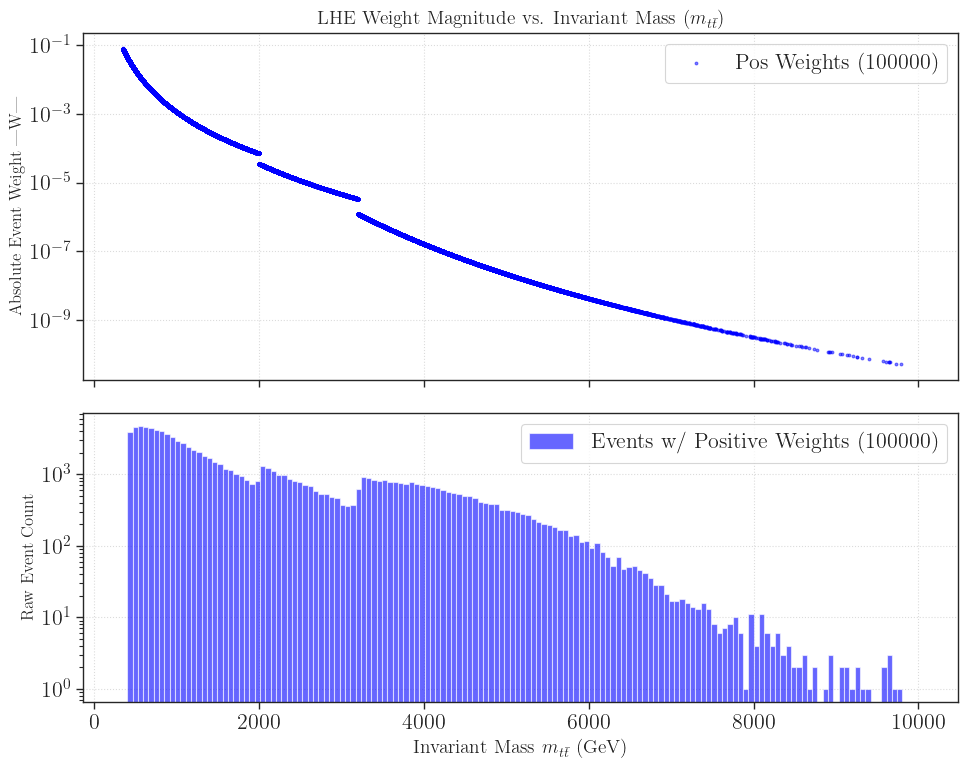

In [11]:



def rapidity(E, pz, eps=1e-12):
    """Calculates the momentum-dependent rapidity of a particle."""
    num, den = E + pz, E - pz
    if num <= eps or den <= eps: return np.nan
    return 0.5 * np.log(num / den)

def pt(px, py):
    """Calculates the transverse momentum (pT)."""
    return np.hypot(px, py)

def phi(px, py):
    """Calculates the azimuthal angle phi."""
    return np.arctan2(py, px)

def delta_phi(phi1, phi2):
    """Calculates the difference in azimuthal angle between two particles."""
    d = phi1 - phi2
    return (d + np.pi) % (2 * np.pi) - np.pi

def mass(E, px, py, pz):
    """Calculates the invariant mass from a 4-momentum vector."""
    m2 = E*E - px*px - py*py - pz*pz
    return np.sqrt(max(m2, 0.0))

def boost_to_rest_frame(p4, parent):
    """
    Performs a Lorentz transformation, boosting a 4-momentum vector (p4) 
    into the rest frame of its parent particle/system.
    """
    E, px, py, pz = p4
    EP, Px, Py, Pz = parent
    bx, by, bz = Px/EP, Py/EP, Pz/EP
    b2 = bx*bx + by*by + bz*bz
    if b2 >= 1.0 or b2 < 1e-16: return np.array([E, px, py, pz], dtype=float)
    gamma = 1.0 / np.sqrt(1.0 - b2)
    bp = bx*px + by*py + bz*pz
    gamma2 = (gamma - 1.0) / b2
    pxp = px + (-gamma * E + gamma2 * bp) * bx
    pyp = py + (-gamma * E + gamma2 * bp) * by
    pzp = pz + (-gamma * E + gamma2 * bp) * bz
    Ep  = gamma * (E - bp)
    return np.array([Ep, pxp, pyp, pzp], dtype=float)

def parse_event_block(lines, rescale_weight_by=1.0):
    """
    Parses a single <event> block from an LHE file, extracting top quark 
    kinematics and calculating macroscopic event-level observables like 
    invariant mass (m_tt) and transverse momentum (pT).
    """
    content = [ln.strip() for ln in lines if ln.strip()]
    if not content: return None

    header = content[0].split()
    nup, xwgtup = int(header[0]), float(header[2]) * rescale_weight_by

    particles = []
    for ln in content[1:1+nup]:
        cols = ln.split()
        if len(cols) < 13: continue
        particles.append({
            "pid": int(cols[0]), "status": int(cols[1]),
            "px": float(cols[6]), "py": float(cols[7]), "pz": float(cols[8]),
            "E":  float(cols[9]), "M": float(cols[10])
        })

    incoming = [p for p in particles if p["status"] == -1]
    final = [p for p in particles if p["status"] == 1]
    tops, tbars = [p for p in final if p["pid"] == 6], [p for p in final if p["pid"] == -6]
    
    if not tops or not tbars: return None

    t, tb = tops[0], tbars[0]
    t4 = np.array([t["E"], t["px"], t["py"], t["pz"]], dtype=float)
    tb4 = np.array([tb["E"], tb["px"], tb["py"], tb["pz"]], dtype=float)
    tt4 = t4 + tb4

    t_star = boost_to_rest_frame(t4, tt4)
    p_star = np.sqrt(t_star[1]**2 + t_star[2]**2 + t_star[3]**2)
    cos_theta_star = np.nan if p_star < 1e-12 else t_star[3] / p_star

    extra = [p for p in final if abs(p["pid"]) in [1,2,3,4,5,21] and abs(p["pid"]) != 6]
    extra_pts = sorted([pt(p["px"], p["py"]) for p in extra], reverse=True)

    y_t, y_tb = rapidity(t["E"], t["pz"]), rapidity(tb["E"], tb["pz"])
    return {
        "weight": xwgtup,
        "m_t": mass(*t4), "m_tbar": mass(*tb4), "m_tt": mass(*tt4),
        "pt_t": pt(t["px"], t["py"]), "pt_tbar": pt(tb["px"], tb["py"]), "pt_tt": pt(tt4[1], tt4[2]),
        "y_t": y_t, "y_tbar": y_tb, "y_tt": rapidity(tt4[0], tt4[3]),
        "abs_delta_y": abs(y_t - y_tb) if np.isfinite(y_t) and np.isfinite(y_tb) else np.nan,
        "cos_theta_star": cos_theta_star,
        "abs_cos_theta_star": abs(cos_theta_star) if np.isfinite(cos_theta_star) else np.nan,
        "ptj1": extra_pts[0] if len(extra_pts) > 0 else 0.0,
    }

def read_lhe_features(filepath, label=None, max_events=None, rescale_weight_by=1.0):
    """
    Iterates through a compressed or raw LHE file, feeding events to the parser 
    and compiling the returned variables into an analysis-ready Pandas DataFrame.
    """
    data = {
        "weight": [], "m_t": [], "m_tbar": [], "m_tt": [],
        "pt_t": [], "pt_tbar": [], "pt_tt": [],
        "y_t": [], "y_tbar": [], "y_tt": [],
        "abs_delta_y": [], "cos_theta_star": [], "abs_cos_theta_star": [], "ptj1": []
    }
    if label: data["label"] = []

    block, in_event = [], False
    event_count = 0
    opener = gzip.open if filepath.endswith(".gz") else open
    
    with opener(filepath, "rt", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc=f"Reading {os.path.basename(filepath)}"):
            if "<event>" in line:
                in_event = True
                block = []
                continue
            if "</event>" in line:
                rec = parse_event_block(block, rescale_weight_by)
                if rec is not None:
                    for key, val in rec.items():
                        data[key].append(val)
                    if label:
                        data["label"].append(label)
                        
                    event_count += 1
                    if max_events and event_count >= max_events: break
                in_event = False
                continue
            if in_event: 
                block.append(line)

    return pd.DataFrame(data)

def get_run_metadata(filepath, is_nlo=False):
    """
    Extracts the true cross-section, LHE cross-section, and event count.
    - LO: Truth is strictly the LHE file.
    - NLO: Truth is strictly the summary.txt file.
    """
    run_dir = os.path.dirname(filepath)
    info = {'nevents': -1, 'xsec_lhe': -1.0, 'xsec_true': -1.0}
    
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    try:
        with gzip.open(filepath, 'rt') as f_in, open(fixedFile, 'w') as f_out:
            for line in f_in:
                if 'generate' not in line:
                    f_out.write(line)
        
        initBlock = pylhe.read_lhe_init(fixedFile)
        info['xsec_lhe'] = initBlock['procInfo'][0]['xSection']
        info['nevents'] = pylhe.read_num_events(fixedFile)
        info['xsec_true'] = info['xsec_lhe'] 
        
    except Exception as e:
        print(f"Error parsing LHE header from {os.path.basename(filepath)}: {e}")
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)

    if is_nlo:
        summary_path = os.path.join(run_dir, 'summary.txt')
        if os.path.isfile(summary_path):
            with open(summary_path, 'r') as f:
                lines = f.readlines()
                
            try:
                target_idx = [i for i, l in enumerate(lines) if 'Total cross section' in l][0]
                xsec_line = lines[target_idx]
                
                if 'DO NOT USE' in xsec_line:
                    scale_idx = [i for i, l in enumerate(lines) if 'Scale variation' in l][0]
                    xsec_line = lines[scale_idx + 2]
                    
                if 'Total cross section' in xsec_line:
                    xsec_line = xsec_line.split(':')[1].strip()
                    
                xsec_line = xsec_line.split(' +')[0].strip().replace('pb', '')
                info['xsec_true'] = float(xsec_line)
            except Exception:
                pass

    if info['nevents'] <= 0:
        banners = glob.glob(os.path.join(run_dir, '*banner*txt'))
        if banners:
            with open(banners[0], 'r') as f:
                banner_data = f.read()
            if '<MGGenerationInfo>' in banner_data:
                gen_info = banner_data.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
                try:
                    info['nevents'] = eval(gen_info.split('\n')[1].split(':')[1].strip())
                except Exception:
                    pass
                    
    return info

def load_lhe_with_corrections(file_pattern, label=None, is_nlo=False, custom_rescale=1.0, max_events=None):
    """
    Finds LHE files and streams them into a DataFrame. 
    Guarantees that sum(weights) exactly equals the true cross section.
    """
    files = glob.glob(file_pattern)
    if not files:
        print(f"Warning: No files found for pattern {file_pattern}")
        return pd.DataFrame(columns=["weight", "m_t", "m_tbar", "m_tt", "pt_t", "pt_tbar", "pt_tt", "label"])
        
    print(f"Loading {label} from {len(files)} LHE files...")
    df_list = []
    
    for f in files:
        info = get_run_metadata(f, is_nlo=is_nlo)
        base_rescale = 1.0
        
        if not is_nlo and info['nevents'] > 0:
            base_rescale = 1.0 / info['nevents']
            
        elif is_nlo and info['xsec_lhe'] > 0 and info['xsec_true'] > 0:
            drift = abs(info['xsec_lhe'] - info['xsec_true']) / info['xsec_true']
            if drift > 0.01:
                bias_factor = info['xsec_true'] / info['xsec_lhe']
                base_rescale = bias_factor
                
                run_name = os.path.basename(os.path.dirname(f))
                print(f"  -> [BIAS DETECTED] {run_name}: Rescaled weights by {bias_factor:.5f} "
                      f"(True: {info['xsec_true']:.5e} pb, LHE: {info['xsec_lhe']:.5e} pb)")
        
        total_rescale = custom_rescale * base_rescale
        df = read_lhe_features(f, label=label, max_events=max_events, rescale_weight_by=total_rescale)
        
        if not df.empty:
            df_list.append(df)
        else:
            print(f"  -> Skipping {os.path.basename(f)} (No valid events)")
            
    if not df_list:
        return pd.DataFrame()
        
    return pd.concat(df_list, ignore_index=True)

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

# Define the file pattern to capture the LHE file
file_pattern = './../processFolders/Scalar_ff/pp2ttbar_gs4_ydm2/Events/bias_test_1000_900/*.lhe.gz'


df = load_lhe_with_corrections(
    file_pattern, 
    label="SM + int", 
    is_nlo=False, 
    custom_rescale=1.0
)

print(f"Loaded {len(df)} events.")

# ==============================================================================
# 2. DATA PROCESSING
# ==============================================================================

# Extract arrays from DataFrame
mtt = df['m_tt'].values
w = df['weight'].values
print(sum(w))

# Separate positive and negative weights (Crucial for NLO FKS Subtraction)
mask_pos = w >= 0
mask_neg = w < 0

mtt_pos, w_pos = mtt[mask_pos], w[mask_pos]
mtt_neg, w_neg = mtt[mask_neg], w[mask_neg]

# ==============================================================================
# 3. PLOTTING
# ==============================================================================

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Scatter plot of magnitudes + Histogram of RAW event counts.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                                          gridspec_kw={'height_ratios': [1.2, 1]})
    
    # TOP PANEL: Magnitude (Scatter) - Keeps the weight info
    ax_mag.scatter(mtt_pos, np.abs(w_pos), color='blue', alpha=0.5, s=4, 
                   label=f'Pos Weights ({len(w_pos)})')
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, 
                       label=f'|Neg Weights| ({len(w_neg)})')
        
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag.set_yscale('log')
    ax_mag.grid(True, linestyle=':', alpha=0.7)
    ax_mag.legend(loc='upper right')

    # BOTTOM PANEL: Phase Space (Histogram - RAW COUNTS)
    # We remove the 'weights=' argument to plot frequency/counts
    bins = np.linspace(400, 10000, 150) 
    
    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, 
                 label=f'Events w/ Positive Weights ({len(mtt_pos)})')
    
    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, 
                     label=f'Events w/ Negative Weights ({len(mtt_neg)})', 
                     histtype='step', linewidth=2)

    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execution with your Data
# ==============================================================================

# 3. Plot
plot_weight_diagnostics(mtt[mask_pos], w[mask_pos], mtt[mask_neg], w[mask_neg])



Loading SM + int from 1 LHE files...


Reading unweighted_events.lhe.gz: 0it [00:00, ?it/s]

Loaded 1000000 events.
473.61999999218244


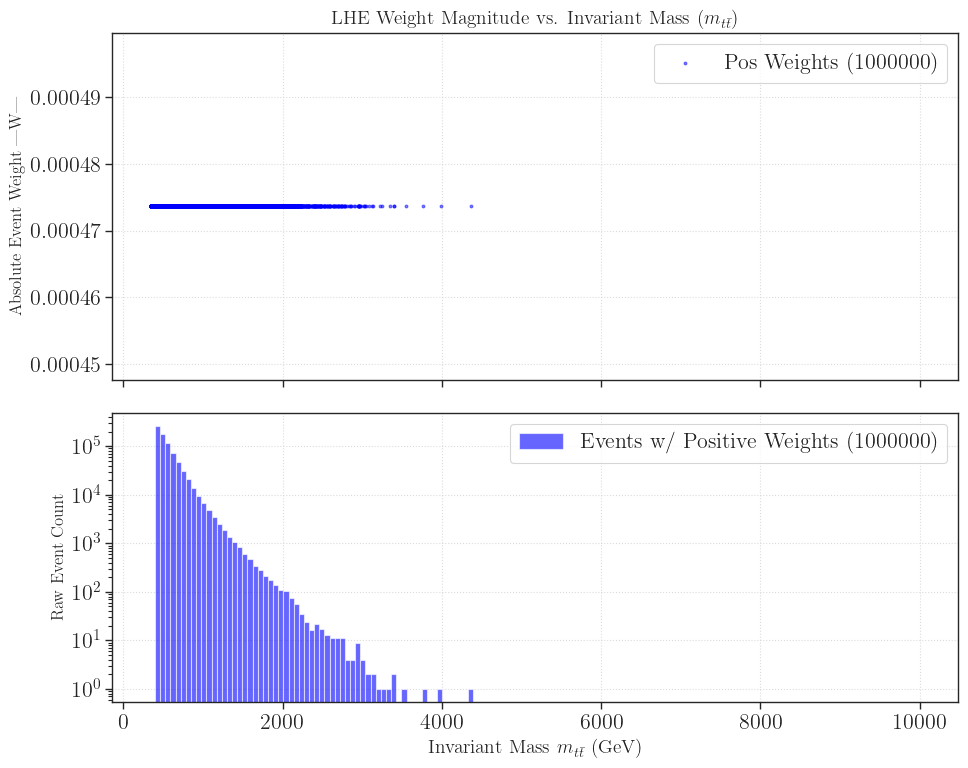

In [3]:


def rapidity(E, pz, eps=1e-12):
    """Calculates the momentum-dependent rapidity of a particle."""
    num, den = E + pz, E - pz
    if num <= eps or den <= eps: return np.nan
    return 0.5 * np.log(num / den)

def pt(px, py):
    """Calculates the transverse momentum (pT)."""
    return np.hypot(px, py)

def phi(px, py):
    """Calculates the azimuthal angle phi."""
    return np.arctan2(py, px)

def delta_phi(phi1, phi2):
    """Calculates the difference in azimuthal angle between two particles."""
    d = phi1 - phi2
    return (d + np.pi) % (2 * np.pi) - np.pi

def mass(E, px, py, pz):
    """Calculates the invariant mass from a 4-momentum vector."""
    m2 = E*E - px*px - py*py - pz*pz
    return np.sqrt(max(m2, 0.0))

def boost_to_rest_frame(p4, parent):
    """
    Performs a Lorentz transformation, boosting a 4-momentum vector (p4) 
    into the rest frame of its parent particle/system.
    """
    E, px, py, pz = p4
    EP, Px, Py, Pz = parent
    bx, by, bz = Px/EP, Py/EP, Pz/EP
    b2 = bx*bx + by*by + bz*bz
    if b2 >= 1.0 or b2 < 1e-16: return np.array([E, px, py, pz], dtype=float)
    gamma = 1.0 / np.sqrt(1.0 - b2)
    bp = bx*px + by*py + bz*pz
    gamma2 = (gamma - 1.0) / b2
    pxp = px + (-gamma * E + gamma2 * bp) * bx
    pyp = py + (-gamma * E + gamma2 * bp) * by
    pzp = pz + (-gamma * E + gamma2 * bp) * bz
    Ep  = gamma * (E - bp)
    return np.array([Ep, pxp, pyp, pzp], dtype=float)

def parse_event_block(lines, rescale_weight_by=1.0):
    """
    Parses a single <event> block from an LHE file, extracting top quark 
    kinematics and calculating macroscopic event-level observables like 
    invariant mass (m_tt) and transverse momentum (pT).
    """
    content = [ln.strip() for ln in lines if ln.strip()]
    if not content: return None

    header = content[0].split()
    nup, xwgtup = int(header[0]), float(header[2]) * rescale_weight_by

    particles = []
    for ln in content[1:1+nup]:
        cols = ln.split()
        if len(cols) < 13: continue
        particles.append({
            "pid": int(cols[0]), "status": int(cols[1]),
            "px": float(cols[6]), "py": float(cols[7]), "pz": float(cols[8]),
            "E":  float(cols[9]), "M": float(cols[10])
        })

    incoming = [p for p in particles if p["status"] == -1]
    final = [p for p in particles if p["status"] == 1]
    tops, tbars = [p for p in final if p["pid"] == 6], [p for p in final if p["pid"] == -6]
    
    if not tops or not tbars: return None

    t, tb = tops[0], tbars[0]
    t4 = np.array([t["E"], t["px"], t["py"], t["pz"]], dtype=float)
    tb4 = np.array([tb["E"], tb["px"], tb["py"], tb["pz"]], dtype=float)
    tt4 = t4 + tb4

    t_star = boost_to_rest_frame(t4, tt4)
    p_star = np.sqrt(t_star[1]**2 + t_star[2]**2 + t_star[3]**2)
    cos_theta_star = np.nan if p_star < 1e-12 else t_star[3] / p_star

    extra = [p for p in final if abs(p["pid"]) in [1,2,3,4,5,21] and abs(p["pid"]) != 6]
    extra_pts = sorted([pt(p["px"], p["py"]) for p in extra], reverse=True)

    y_t, y_tb = rapidity(t["E"], t["pz"]), rapidity(tb["E"], tb["pz"])
    return {
        "weight": xwgtup,
        "m_t": mass(*t4), "m_tbar": mass(*tb4), "m_tt": mass(*tt4),
        "pt_t": pt(t["px"], t["py"]), "pt_tbar": pt(tb["px"], tb["py"]), "pt_tt": pt(tt4[1], tt4[2]),
        "y_t": y_t, "y_tbar": y_tb, "y_tt": rapidity(tt4[0], tt4[3]),
        "abs_delta_y": abs(y_t - y_tb) if np.isfinite(y_t) and np.isfinite(y_tb) else np.nan,
        "cos_theta_star": cos_theta_star,
        "abs_cos_theta_star": abs(cos_theta_star) if np.isfinite(cos_theta_star) else np.nan,
        "ptj1": extra_pts[0] if len(extra_pts) > 0 else 0.0,
    }

def read_lhe_features(filepath, label=None, max_events=None, rescale_weight_by=1.0):
    """
    Iterates through a compressed or raw LHE file, feeding events to the parser 
    and compiling the returned variables into an analysis-ready Pandas DataFrame.
    """
    data = {
        "weight": [], "m_t": [], "m_tbar": [], "m_tt": [],
        "pt_t": [], "pt_tbar": [], "pt_tt": [],
        "y_t": [], "y_tbar": [], "y_tt": [],
        "abs_delta_y": [], "cos_theta_star": [], "abs_cos_theta_star": [], "ptj1": []
    }
    if label: data["label"] = []

    block, in_event = [], False
    event_count = 0
    opener = gzip.open if filepath.endswith(".gz") else open
    
    with opener(filepath, "rt", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc=f"Reading {os.path.basename(filepath)}"):
            if "<event>" in line:
                in_event = True
                block = []
                continue
            if "</event>" in line:
                rec = parse_event_block(block, rescale_weight_by)
                if rec is not None:
                    for key, val in rec.items():
                        data[key].append(val)
                    if label:
                        data["label"].append(label)
                        
                    event_count += 1
                    if max_events and event_count >= max_events: break
                in_event = False
                continue
            if in_event: 
                block.append(line)

    return pd.DataFrame(data)

def get_run_metadata(filepath, is_nlo=False):
    """
    Extracts the true cross-section, LHE cross-section, and event count.
    - LO: Truth is strictly the LHE file.
    - NLO: Truth is strictly the summary.txt file.
    """
    run_dir = os.path.dirname(filepath)
    info = {'nevents': -1, 'xsec_lhe': -1.0, 'xsec_true': -1.0}
    
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    try:
        with gzip.open(filepath, 'rt') as f_in, open(fixedFile, 'w') as f_out:
            for line in f_in:
                if 'generate' not in line:
                    f_out.write(line)
        
        initBlock = pylhe.read_lhe_init(fixedFile)
        info['xsec_lhe'] = initBlock['procInfo'][0]['xSection']
        info['nevents'] = pylhe.read_num_events(fixedFile)
        info['xsec_true'] = info['xsec_lhe'] 
        
    except Exception as e:
        print(f"Error parsing LHE header from {os.path.basename(filepath)}: {e}")
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)

    if is_nlo:
        summary_path = os.path.join(run_dir, 'summary.txt')
        if os.path.isfile(summary_path):
            with open(summary_path, 'r') as f:
                lines = f.readlines()
                
            try:
                target_idx = [i for i, l in enumerate(lines) if 'Total cross section' in l][0]
                xsec_line = lines[target_idx]
                
                if 'DO NOT USE' in xsec_line:
                    scale_idx = [i for i, l in enumerate(lines) if 'Scale variation' in l][0]
                    xsec_line = lines[scale_idx + 2]
                    
                if 'Total cross section' in xsec_line:
                    xsec_line = xsec_line.split(':')[1].strip()
                    
                xsec_line = xsec_line.split(' +')[0].strip().replace('pb', '')
                info['xsec_true'] = float(xsec_line)
            except Exception:
                pass

    if info['nevents'] <= 0:
        banners = glob.glob(os.path.join(run_dir, '*banner*txt'))
        if banners:
            with open(banners[0], 'r') as f:
                banner_data = f.read()
            if '<MGGenerationInfo>' in banner_data:
                gen_info = banner_data.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
                try:
                    info['nevents'] = eval(gen_info.split('\n')[1].split(':')[1].strip())
                except Exception:
                    pass
                    
    return info

def load_lhe_with_corrections(file_pattern, label=None, is_nlo=False, custom_rescale=1.0, max_events=None):
    """
    Finds LHE files and streams them into a DataFrame. 
    Guarantees that sum(weights) exactly equals the true cross section.
    """
    files = glob.glob(file_pattern)
    if not files:
        print(f"Warning: No files found for pattern {file_pattern}")
        return pd.DataFrame(columns=["weight", "m_t", "m_tbar", "m_tt", "pt_t", "pt_tbar", "pt_tt", "label"])
        
    print(f"Loading {label} from {len(files)} LHE files...")
    df_list = []
    
    for f in files:
        info = get_run_metadata(f, is_nlo=is_nlo)
        base_rescale = 1.0
        
        if not is_nlo and info['nevents'] > 0:
            base_rescale = 1.0 / info['nevents']
            
        elif is_nlo and info['xsec_lhe'] > 0 and info['xsec_true'] > 0:
            drift = abs(info['xsec_lhe'] - info['xsec_true']) / info['xsec_true']
            if drift > 0.01:
                bias_factor = info['xsec_true'] / info['xsec_lhe']
                base_rescale = bias_factor
                
                run_name = os.path.basename(os.path.dirname(f))
                print(f"  -> [BIAS DETECTED] {run_name}: Rescaled weights by {bias_factor:.5f} "
                      f"(True: {info['xsec_true']:.5e} pb, LHE: {info['xsec_lhe']:.5e} pb)")
        
        total_rescale = custom_rescale * base_rescale
        df = read_lhe_features(f, label=label, max_events=max_events, rescale_weight_by=total_rescale)
        
        if not df.empty:
            df_list.append(df)
        else:
            print(f"  -> Skipping {os.path.basename(f)} (No valid events)")
            
    if not df_list:
        return pd.DataFrame()
        
    return pd.concat(df_list, ignore_index=True)

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

# Define the file pattern to capture the LHE file
file_pattern = './../processFolders/Scalar_ff/pp2ttbar_gs4_ydm4/Events/bias_fullAmp_1000_900/*.lhe.gz'


df = load_lhe_with_corrections(
    file_pattern, 
    label="SM + int", 
    is_nlo=False, 
    custom_rescale=1.0
)

print(f"Loaded {len(df)} events.")

# ==============================================================================
# 2. DATA PROCESSING
# ==============================================================================

# Extract arrays from DataFrame
mtt = df['m_tt'].values
w = df['weight'].values
print(sum(w))

# Separate positive and negative weights (Crucial for NLO FKS Subtraction)
mask_pos = w >= 0
mask_neg = w < 0

mtt_pos, w_pos = mtt[mask_pos], w[mask_pos]
mtt_neg, w_neg = mtt[mask_neg], w[mask_neg]

# ==============================================================================
# 3. PLOTTING
# ==============================================================================

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Scatter plot of magnitudes + Histogram of RAW event counts.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                                          gridspec_kw={'height_ratios': [1.2, 1]})
    
    # TOP PANEL: Magnitude (Scatter) - Keeps the weight info
    ax_mag.scatter(mtt_pos, np.abs(w_pos), color='blue', alpha=0.5, s=4, 
                   label=f'Pos Weights ({len(w_pos)})')
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, 
                       label=f'|Neg Weights| ({len(w_neg)})')
        
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    #ax_mag.set_yscale('log')
    ax_mag.grid(True, linestyle=':', alpha=0.7)
    ax_mag.legend(loc='upper right')

    # BOTTOM PANEL: Phase Space (Histogram - RAW COUNTS)
    # We remove the 'weights=' argument to plot frequency/counts
    bins = np.linspace(400, 10000, 150) 
    
    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, 
                 label=f'Events w/ Positive Weights ({len(mtt_pos)})')
    
    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, 
                     label=f'Events w/ Negative Weights ({len(mtt_neg)})', 
                     histtype='step', linewidth=2)

    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execution with your Data
# ==============================================================================

# 3. Plot
plot_weight_diagnostics(mtt[mask_pos], w[mask_pos], mtt[mask_neg], w[mask_neg])



Loading SM + int from 2 LHE files...


Reading events.lhe.gz: 0it [00:00, ?it/s]

Error parsing LHE header from RunMaterial.tar.gz: not well-formed (invalid token): line 1, column 11


Reading RunMaterial.tar.gz: 0it [00:00, ?it/s]

  -> Skipping RunMaterial.tar.gz (No valid events)
Loaded 1869863 events.
4.405840379605426e-06


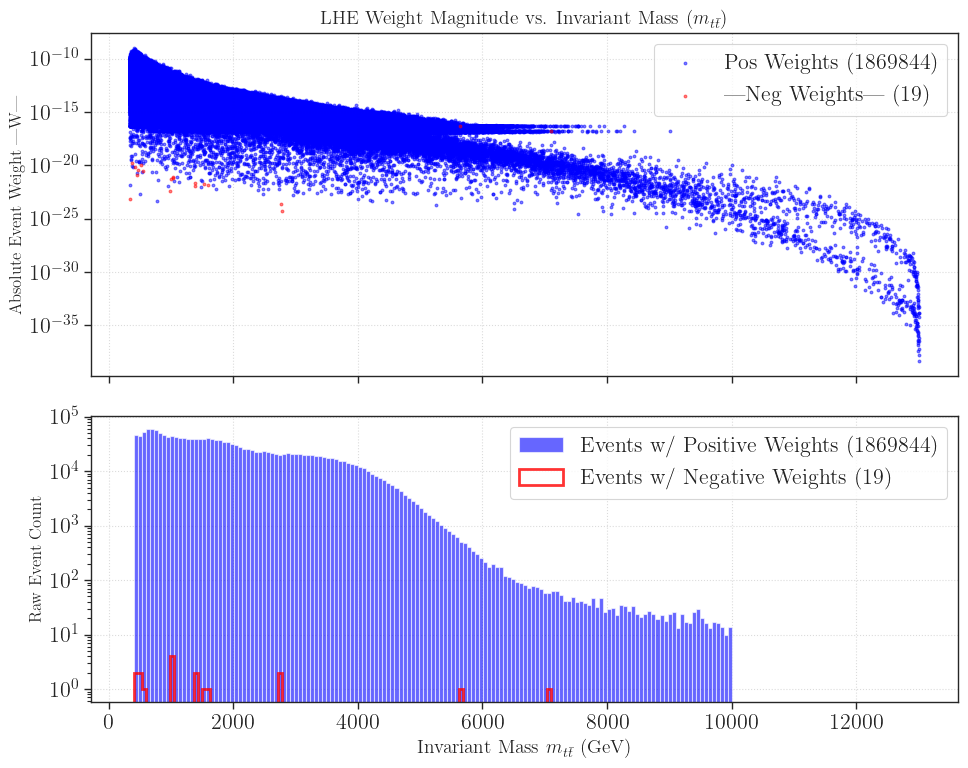

In [12]:


def rapidity(E, pz, eps=1e-12):
    """Calculates the momentum-dependent rapidity of a particle."""
    num, den = E + pz, E - pz
    if num <= eps or den <= eps: return np.nan
    return 0.5 * np.log(num / den)

def pt(px, py):
    """Calculates the transverse momentum (pT)."""
    return np.hypot(px, py)

def phi(px, py):
    """Calculates the azimuthal angle phi."""
    return np.arctan2(py, px)

def delta_phi(phi1, phi2):
    """Calculates the difference in azimuthal angle between two particles."""
    d = phi1 - phi2
    return (d + np.pi) % (2 * np.pi) - np.pi

def mass(E, px, py, pz):
    """Calculates the invariant mass from a 4-momentum vector."""
    m2 = E*E - px*px - py*py - pz*pz
    return np.sqrt(max(m2, 0.0))

def boost_to_rest_frame(p4, parent):
    """
    Performs a Lorentz transformation, boosting a 4-momentum vector (p4) 
    into the rest frame of its parent particle/system.
    """
    E, px, py, pz = p4
    EP, Px, Py, Pz = parent
    bx, by, bz = Px/EP, Py/EP, Pz/EP
    b2 = bx*bx + by*by + bz*bz
    if b2 >= 1.0 or b2 < 1e-16: return np.array([E, px, py, pz], dtype=float)
    gamma = 1.0 / np.sqrt(1.0 - b2)
    bp = bx*px + by*py + bz*pz
    gamma2 = (gamma - 1.0) / b2
    pxp = px + (-gamma * E + gamma2 * bp) * bx
    pyp = py + (-gamma * E + gamma2 * bp) * by
    pzp = pz + (-gamma * E + gamma2 * bp) * bz
    Ep  = gamma * (E - bp)
    return np.array([Ep, pxp, pyp, pzp], dtype=float)

def parse_event_block(lines, rescale_weight_by=1.0):
    """
    Parses a single <event> block from an LHE file, extracting top quark 
    kinematics and calculating macroscopic event-level observables like 
    invariant mass (m_tt) and transverse momentum (pT).
    """
    content = [ln.strip() for ln in lines if ln.strip()]
    if not content: return None

    header = content[0].split()
    nup, xwgtup = int(header[0]), float(header[2]) * rescale_weight_by

    particles = []
    for ln in content[1:1+nup]:
        cols = ln.split()
        if len(cols) < 13: continue
        particles.append({
            "pid": int(cols[0]), "status": int(cols[1]),
            "px": float(cols[6]), "py": float(cols[7]), "pz": float(cols[8]),
            "E":  float(cols[9]), "M": float(cols[10])
        })

    incoming = [p for p in particles if p["status"] == -1]
    final = [p for p in particles if p["status"] == 1]
    tops, tbars = [p for p in final if p["pid"] == 6], [p for p in final if p["pid"] == -6]
    
    if not tops or not tbars: return None

    t, tb = tops[0], tbars[0]
    t4 = np.array([t["E"], t["px"], t["py"], t["pz"]], dtype=float)
    tb4 = np.array([tb["E"], tb["px"], tb["py"], tb["pz"]], dtype=float)
    tt4 = t4 + tb4

    t_star = boost_to_rest_frame(t4, tt4)
    p_star = np.sqrt(t_star[1]**2 + t_star[2]**2 + t_star[3]**2)
    cos_theta_star = np.nan if p_star < 1e-12 else t_star[3] / p_star

    extra = [p for p in final if abs(p["pid"]) in [1,2,3,4,5,21] and abs(p["pid"]) != 6]
    extra_pts = sorted([pt(p["px"], p["py"]) for p in extra], reverse=True)

    y_t, y_tb = rapidity(t["E"], t["pz"]), rapidity(tb["E"], tb["pz"])
    return {
        "weight": xwgtup,
        "m_t": mass(*t4), "m_tbar": mass(*tb4), "m_tt": mass(*tt4),
        "pt_t": pt(t["px"], t["py"]), "pt_tbar": pt(tb["px"], tb["py"]), "pt_tt": pt(tt4[1], tt4[2]),
        "y_t": y_t, "y_tbar": y_tb, "y_tt": rapidity(tt4[0], tt4[3]),
        "abs_delta_y": abs(y_t - y_tb) if np.isfinite(y_t) and np.isfinite(y_tb) else np.nan,
        "cos_theta_star": cos_theta_star,
        "abs_cos_theta_star": abs(cos_theta_star) if np.isfinite(cos_theta_star) else np.nan,
        "ptj1": extra_pts[0] if len(extra_pts) > 0 else 0.0,
    }

def read_lhe_features(filepath, label=None, max_events=None, rescale_weight_by=1.0):
    """
    Iterates through a compressed or raw LHE file, feeding events to the parser 
    and compiling the returned variables into an analysis-ready Pandas DataFrame.
    """
    data = {
        "weight": [], "m_t": [], "m_tbar": [], "m_tt": [],
        "pt_t": [], "pt_tbar": [], "pt_tt": [],
        "y_t": [], "y_tbar": [], "y_tt": [],
        "abs_delta_y": [], "cos_theta_star": [], "abs_cos_theta_star": [], "ptj1": []
    }
    if label: data["label"] = []

    block, in_event = [], False
    event_count = 0
    opener = gzip.open if filepath.endswith(".gz") else open
    
    with opener(filepath, "rt", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc=f"Reading {os.path.basename(filepath)}"):
            if "<event>" in line:
                in_event = True
                block = []
                continue
            if "</event>" in line:
                rec = parse_event_block(block, rescale_weight_by)
                if rec is not None:
                    for key, val in rec.items():
                        data[key].append(val)
                    if label:
                        data["label"].append(label)
                        
                    event_count += 1
                    if max_events and event_count >= max_events: break
                in_event = False
                continue
            if in_event: 
                block.append(line)

    return pd.DataFrame(data)

def get_run_metadata(filepath, is_nlo=False):
    """
    Extracts the true cross-section, LHE cross-section, and event count.
    - LO: Truth is strictly the LHE file.
    - NLO: Truth is strictly the summary.txt file.
    """
    run_dir = os.path.dirname(filepath)
    info = {'nevents': -1, 'xsec_lhe': -1.0, 'xsec_true': -1.0}
    
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    try:
        with gzip.open(filepath, 'rt') as f_in, open(fixedFile, 'w') as f_out:
            for line in f_in:
                if 'generate' not in line:
                    f_out.write(line)
        
        initBlock = pylhe.read_lhe_init(fixedFile)
        info['xsec_lhe'] = initBlock['procInfo'][0]['xSection']
        info['nevents'] = pylhe.read_num_events(fixedFile)
        info['xsec_true'] = info['xsec_lhe'] 
        
    except Exception as e:
        print(f"Error parsing LHE header from {os.path.basename(filepath)}: {e}")
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)

    if is_nlo:
        summary_path = os.path.join(run_dir, 'summary.txt')
        if os.path.isfile(summary_path):
            with open(summary_path, 'r') as f:
                lines = f.readlines()
                
            try:
                target_idx = [i for i, l in enumerate(lines) if 'Total cross section' in l][0]
                xsec_line = lines[target_idx]
                
                if 'DO NOT USE' in xsec_line:
                    scale_idx = [i for i, l in enumerate(lines) if 'Scale variation' in l][0]
                    xsec_line = lines[scale_idx + 2]
                    
                if 'Total cross section' in xsec_line:
                    xsec_line = xsec_line.split(':')[1].strip()
                    
                xsec_line = xsec_line.split(' +')[0].strip().replace('pb', '')
                info['xsec_true'] = float(xsec_line)
            except Exception:
                pass

    if info['nevents'] <= 0:
        banners = glob.glob(os.path.join(run_dir, '*banner*txt'))
        if banners:
            with open(banners[0], 'r') as f:
                banner_data = f.read()
            if '<MGGenerationInfo>' in banner_data:
                gen_info = banner_data.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
                try:
                    info['nevents'] = eval(gen_info.split('\n')[1].split(':')[1].strip())
                except Exception:
                    pass
                    
    return info

def load_lhe_with_corrections(file_pattern, label=None, is_nlo=False, custom_rescale=1.0, max_events=None):
    """
    Finds LHE files and streams them into a DataFrame. 
    Guarantees that sum(weights) exactly equals the true cross section.
    """
    files = glob.glob(file_pattern)
    if not files:
        print(f"Warning: No files found for pattern {file_pattern}")
        return pd.DataFrame(columns=["weight", "m_t", "m_tbar", "m_tt", "pt_t", "pt_tbar", "pt_tt", "label"])
        
    print(f"Loading {label} from {len(files)} LHE files...")
    df_list = []
    
    for f in files:
        info = get_run_metadata(f, is_nlo=is_nlo)
        base_rescale = 1.0
        
        if not is_nlo and info['nevents'] > 0:
            base_rescale = 1.0 / info['nevents']
            
        elif is_nlo and info['xsec_lhe'] > 0 and info['xsec_true'] > 0:
            drift = abs(info['xsec_lhe'] - info['xsec_true']) / info['xsec_true']
            if drift > 0.01:
                bias_factor = info['xsec_true'] / info['xsec_lhe']
                base_rescale = bias_factor
                
                run_name = os.path.basename(os.path.dirname(f))
                print(f"  -> [BIAS DETECTED] {run_name}: Rescaled weights by {bias_factor:.5f} "
                      f"(True: {info['xsec_true']:.5e} pb, LHE: {info['xsec_lhe']:.5e} pb)")
        
        total_rescale = custom_rescale * base_rescale
        df = read_lhe_features(f, label=label, max_events=max_events, rescale_weight_by=total_rescale)
        
        if not df.empty:
            df_list.append(df)
        else:
            print(f"  -> Skipping {os.path.basename(f)} (No valid events)")
            
    if not df_list:
        return pd.DataFrame()
        
    return pd.concat(df_list, ignore_index=True)

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

# Define the file pattern to capture the LHE file
file_pattern = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_negW_test2_1000_900/*.gz'


df = load_lhe_with_corrections(
    file_pattern, 
    label="SM + int", 
    is_nlo=False, 
    custom_rescale=1.0
)

print(f"Loaded {len(df)} events.")

# ==============================================================================
# 2. DATA PROCESSING
# ==============================================================================

# Extract arrays from DataFrame
mtt = df['m_tt'].values
w = df['weight'].values
print(sum(w))

# Separate positive and negative weights (Crucial for NLO FKS Subtraction)
mask_pos = w >= 0
mask_neg = w < 0

mtt_pos, w_pos = mtt[mask_pos], w[mask_pos]
mtt_neg, w_neg = mtt[mask_neg], w[mask_neg]

# ==============================================================================
# 3. PLOTTING
# ==============================================================================

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Scatter plot of magnitudes + Histogram of RAW event counts.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                                          gridspec_kw={'height_ratios': [1.2, 1]})
    
    # TOP PANEL: Magnitude (Scatter) - Keeps the weight info
    ax_mag.scatter(mtt_pos, np.abs(w_pos), color='blue', alpha=0.5, s=4, 
                   label=f'Pos Weights ({len(w_pos)})')
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, 
                       label=f'|Neg Weights| ({len(w_neg)})')
        
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag.set_yscale('log')
    ax_mag.grid(True, linestyle=':', alpha=0.7)
    ax_mag.legend(loc='upper right')

    # BOTTOM PANEL: Phase Space (Histogram - RAW COUNTS)
    # We remove the 'weights=' argument to plot frequency/counts
    bins = np.linspace(400, 10000, 150) 
    
    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, 
                 label=f'Events w/ Positive Weights ({len(mtt_pos)})')
    
    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, 
                     label=f'Events w/ Negative Weights ({len(mtt_neg)})', 
                     histtype='step', linewidth=2)

    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execution with your Data
# ==============================================================================

# 3. Plot
plot_weight_diagnostics(mtt[mask_pos], w[mask_pos], mtt[mask_neg], w[mask_neg])



Loading SM + int from 2 LHE files...


Reading events.lhe.gz: 0it [00:00, ?it/s]

Error parsing LHE header from RunMaterial.tar.gz: not well-formed (invalid token): line 1, column 11


Reading RunMaterial.tar.gz: 0it [00:00, ?it/s]

  -> Skipping RunMaterial.tar.gz (No valid events)
Loaded 1869863 events.
4.405840379605426e-06


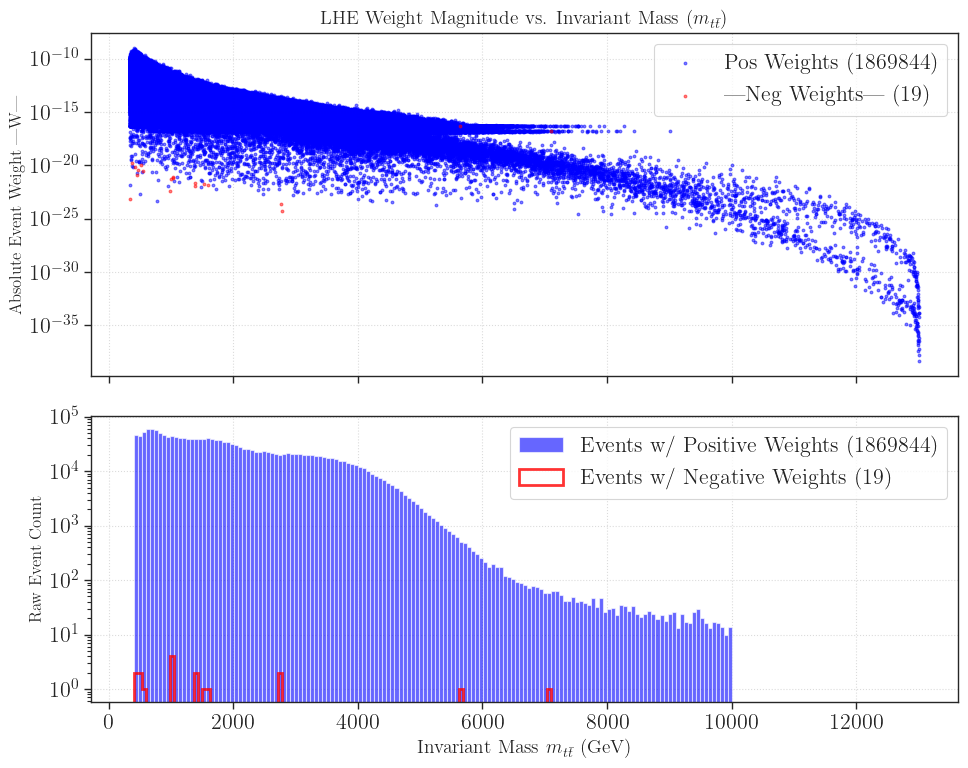

Loading SM + int from 2 LHE files...


Reading events.lhe.gz: 0it [00:00, ?it/s]

Error parsing LHE header from RunMaterial.tar.gz: not well-formed (invalid token): line 1, column 11


Reading RunMaterial.tar.gz: 0it [00:00, ?it/s]

  -> Skipping RunMaterial.tar.gz (No valid events)
Loaded 2035748 events.
4.124772836118049e-06


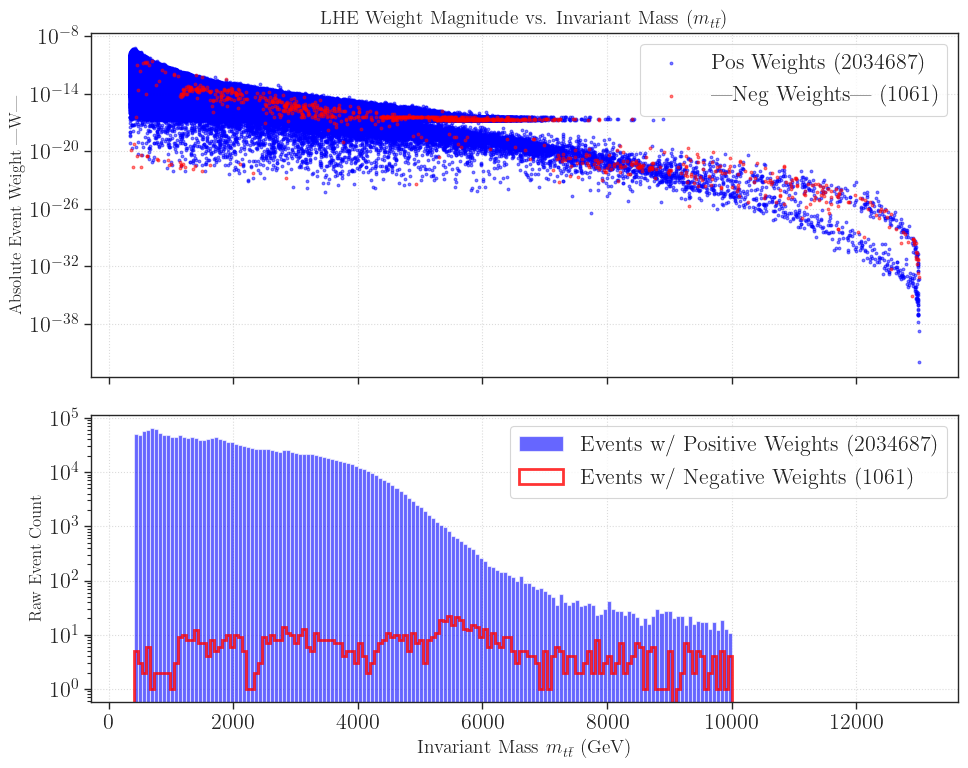

In [13]:


def rapidity(E, pz, eps=1e-12):
    """Calculates the momentum-dependent rapidity of a particle."""
    num, den = E + pz, E - pz
    if num <= eps or den <= eps: return np.nan
    return 0.5 * np.log(num / den)

def pt(px, py):
    """Calculates the transverse momentum (pT)."""
    return np.hypot(px, py)

def phi(px, py):
    """Calculates the azimuthal angle phi."""
    return np.arctan2(py, px)

def delta_phi(phi1, phi2):
    """Calculates the difference in azimuthal angle between two particles."""
    d = phi1 - phi2
    return (d + np.pi) % (2 * np.pi) - np.pi

def mass(E, px, py, pz):
    """Calculates the invariant mass from a 4-momentum vector."""
    m2 = E*E - px*px - py*py - pz*pz
    return np.sqrt(max(m2, 0.0))

def boost_to_rest_frame(p4, parent):
    """
    Performs a Lorentz transformation, boosting a 4-momentum vector (p4) 
    into the rest frame of its parent particle/system.
    """
    E, px, py, pz = p4
    EP, Px, Py, Pz = parent
    bx, by, bz = Px/EP, Py/EP, Pz/EP
    b2 = bx*bx + by*by + bz*bz
    if b2 >= 1.0 or b2 < 1e-16: return np.array([E, px, py, pz], dtype=float)
    gamma = 1.0 / np.sqrt(1.0 - b2)
    bp = bx*px + by*py + bz*pz
    gamma2 = (gamma - 1.0) / b2
    pxp = px + (-gamma * E + gamma2 * bp) * bx
    pyp = py + (-gamma * E + gamma2 * bp) * by
    pzp = pz + (-gamma * E + gamma2 * bp) * bz
    Ep  = gamma * (E - bp)
    return np.array([Ep, pxp, pyp, pzp], dtype=float)

def parse_event_block(lines, rescale_weight_by=1.0):
    """
    Parses a single <event> block from an LHE file, extracting top quark 
    kinematics and calculating macroscopic event-level observables like 
    invariant mass (m_tt) and transverse momentum (pT).
    """
    content = [ln.strip() for ln in lines if ln.strip()]
    if not content: return None

    header = content[0].split()
    nup, xwgtup = int(header[0]), float(header[2]) * rescale_weight_by

    particles = []
    for ln in content[1:1+nup]:
        cols = ln.split()
        if len(cols) < 13: continue
        particles.append({
            "pid": int(cols[0]), "status": int(cols[1]),
            "px": float(cols[6]), "py": float(cols[7]), "pz": float(cols[8]),
            "E":  float(cols[9]), "M": float(cols[10])
        })

    incoming = [p for p in particles if p["status"] == -1]
    final = [p for p in particles if p["status"] == 1]
    tops, tbars = [p for p in final if p["pid"] == 6], [p for p in final if p["pid"] == -6]
    
    if not tops or not tbars: return None

    t, tb = tops[0], tbars[0]
    t4 = np.array([t["E"], t["px"], t["py"], t["pz"]], dtype=float)
    tb4 = np.array([tb["E"], tb["px"], tb["py"], tb["pz"]], dtype=float)
    tt4 = t4 + tb4

    t_star = boost_to_rest_frame(t4, tt4)
    p_star = np.sqrt(t_star[1]**2 + t_star[2]**2 + t_star[3]**2)
    cos_theta_star = np.nan if p_star < 1e-12 else t_star[3] / p_star

    extra = [p for p in final if abs(p["pid"]) in [1,2,3,4,5,21] and abs(p["pid"]) != 6]
    extra_pts = sorted([pt(p["px"], p["py"]) for p in extra], reverse=True)

    y_t, y_tb = rapidity(t["E"], t["pz"]), rapidity(tb["E"], tb["pz"])
    return {
        "weight": xwgtup,
        "m_t": mass(*t4), "m_tbar": mass(*tb4), "m_tt": mass(*tt4),
        "pt_t": pt(t["px"], t["py"]), "pt_tbar": pt(tb["px"], tb["py"]), "pt_tt": pt(tt4[1], tt4[2]),
        "y_t": y_t, "y_tbar": y_tb, "y_tt": rapidity(tt4[0], tt4[3]),
        "abs_delta_y": abs(y_t - y_tb) if np.isfinite(y_t) and np.isfinite(y_tb) else np.nan,
        "cos_theta_star": cos_theta_star,
        "abs_cos_theta_star": abs(cos_theta_star) if np.isfinite(cos_theta_star) else np.nan,
        "ptj1": extra_pts[0] if len(extra_pts) > 0 else 0.0,
    }

def read_lhe_features(filepath, label=None, max_events=None, rescale_weight_by=1.0):
    """
    Iterates through a compressed or raw LHE file, feeding events to the parser 
    and compiling the returned variables into an analysis-ready Pandas DataFrame.
    """
    data = {
        "weight": [], "m_t": [], "m_tbar": [], "m_tt": [],
        "pt_t": [], "pt_tbar": [], "pt_tt": [],
        "y_t": [], "y_tbar": [], "y_tt": [],
        "abs_delta_y": [], "cos_theta_star": [], "abs_cos_theta_star": [], "ptj1": []
    }
    if label: data["label"] = []

    block, in_event = [], False
    event_count = 0
    opener = gzip.open if filepath.endswith(".gz") else open
    
    with opener(filepath, "rt", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc=f"Reading {os.path.basename(filepath)}"):
            if "<event>" in line:
                in_event = True
                block = []
                continue
            if "</event>" in line:
                rec = parse_event_block(block, rescale_weight_by)
                if rec is not None:
                    for key, val in rec.items():
                        data[key].append(val)
                    if label:
                        data["label"].append(label)
                        
                    event_count += 1
                    if max_events and event_count >= max_events: break
                in_event = False
                continue
            if in_event: 
                block.append(line)

    return pd.DataFrame(data)

def get_run_metadata(filepath, is_nlo=False):
    """
    Extracts the true cross-section, LHE cross-section, and event count.
    - LO: Truth is strictly the LHE file.
    - NLO: Truth is strictly the summary.txt file.
    """
    run_dir = os.path.dirname(filepath)
    info = {'nevents': -1, 'xsec_lhe': -1.0, 'xsec_true': -1.0}
    
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    try:
        with gzip.open(filepath, 'rt') as f_in, open(fixedFile, 'w') as f_out:
            for line in f_in:
                if 'generate' not in line:
                    f_out.write(line)
        
        initBlock = pylhe.read_lhe_init(fixedFile)
        info['xsec_lhe'] = initBlock['procInfo'][0]['xSection']
        info['nevents'] = pylhe.read_num_events(fixedFile)
        info['xsec_true'] = info['xsec_lhe'] 
        
    except Exception as e:
        print(f"Error parsing LHE header from {os.path.basename(filepath)}: {e}")
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)

    if is_nlo:
        summary_path = os.path.join(run_dir, 'summary.txt')
        if os.path.isfile(summary_path):
            with open(summary_path, 'r') as f:
                lines = f.readlines()
                
            try:
                target_idx = [i for i, l in enumerate(lines) if 'Total cross section' in l][0]
                xsec_line = lines[target_idx]
                
                if 'DO NOT USE' in xsec_line:
                    scale_idx = [i for i, l in enumerate(lines) if 'Scale variation' in l][0]
                    xsec_line = lines[scale_idx + 2]
                    
                if 'Total cross section' in xsec_line:
                    xsec_line = xsec_line.split(':')[1].strip()
                    
                xsec_line = xsec_line.split(' +')[0].strip().replace('pb', '')
                info['xsec_true'] = float(xsec_line)
            except Exception:
                pass

    if info['nevents'] <= 0:
        banners = glob.glob(os.path.join(run_dir, '*banner*txt'))
        if banners:
            with open(banners[0], 'r') as f:
                banner_data = f.read()
            if '<MGGenerationInfo>' in banner_data:
                gen_info = banner_data.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
                try:
                    info['nevents'] = eval(gen_info.split('\n')[1].split(':')[1].strip())
                except Exception:
                    pass
                    
    return info

def load_lhe_with_corrections(file_pattern, label=None, is_nlo=False, custom_rescale=1.0, max_events=None):
    """
    Finds LHE files and streams them into a DataFrame. 
    Guarantees that sum(weights) exactly equals the true cross section.
    """
    files = glob.glob(file_pattern)
    if not files:
        print(f"Warning: No files found for pattern {file_pattern}")
        return pd.DataFrame(columns=["weight", "m_t", "m_tbar", "m_tt", "pt_t", "pt_tbar", "pt_tt", "label"])
        
    print(f"Loading {label} from {len(files)} LHE files...")
    df_list = []
    
    for f in files:
        info = get_run_metadata(f, is_nlo=is_nlo)
        base_rescale = 1.0
        
        if not is_nlo and info['nevents'] > 0:
            base_rescale = 1.0 / info['nevents']
            
        elif is_nlo and info['xsec_lhe'] > 0 and info['xsec_true'] > 0:
            drift = abs(info['xsec_lhe'] - info['xsec_true']) / info['xsec_true']
            if drift > 0.01:
                bias_factor = info['xsec_true'] / info['xsec_lhe']
                base_rescale = bias_factor
                
                run_name = os.path.basename(os.path.dirname(f))
                print(f"  -> [BIAS DETECTED] {run_name}: Rescaled weights by {bias_factor:.5f} "
                      f"(True: {info['xsec_true']:.5e} pb, LHE: {info['xsec_lhe']:.5e} pb)")
        
        total_rescale = custom_rescale * base_rescale
        df = read_lhe_features(f, label=label, max_events=max_events, rescale_weight_by=total_rescale)
        
        if not df.empty:
            df_list.append(df)
        else:
            print(f"  -> Skipping {os.path.basename(f)} (No valid events)")
            
    if not df_list:
        return pd.DataFrame()
        
    return pd.concat(df_list, ignore_index=True)

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

# Define the file pattern to capture the LHE file
file_pattern = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_negW_test2_1000_900/*.gz'


df = load_lhe_with_corrections(
    file_pattern, 
    label="SM + int", 
    is_nlo=False, 
    custom_rescale=1.0
)

print(f"Loaded {len(df)} events.")

# ==============================================================================
# 2. DATA PROCESSING
# ==============================================================================

# Extract arrays from DataFrame
mtt = df['m_tt'].values
w = df['weight'].values
print(sum(w))

# Separate positive and negative weights (Crucial for NLO FKS Subtraction)
mask_pos = w >= 0
mask_neg = w < 0

mtt_pos, w_pos = mtt[mask_pos], w[mask_pos]
mtt_neg, w_neg = mtt[mask_neg], w[mask_neg]

# ==============================================================================
# 3. PLOTTING
# ==============================================================================

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Scatter plot of magnitudes + Histogram of RAW event counts.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                                          gridspec_kw={'height_ratios': [1.2, 1]})
    
    # TOP PANEL: Magnitude (Scatter) - Keeps the weight info
    ax_mag.scatter(mtt_pos, np.abs(w_pos), color='blue', alpha=0.5, s=4, 
                   label=f'Pos Weights ({len(w_pos)})')
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, 
                       label=f'|Neg Weights| ({len(w_neg)})')
        
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag.set_yscale('log')
    ax_mag.grid(True, linestyle=':', alpha=0.7)
    ax_mag.legend(loc='upper right')

    # BOTTOM PANEL: Phase Space (Histogram - RAW COUNTS)
    # We remove the 'weights=' argument to plot frequency/counts
    bins = np.linspace(400, 10000, 150) 
    
    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, 
                 label=f'Events w/ Positive Weights ({len(mtt_pos)})')
    
    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, 
                     label=f'Events w/ Negative Weights ({len(mtt_neg)})', 
                     histtype='step', linewidth=2)

    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execution with your Data
# ==============================================================================

# 3. Plot
plot_weight_diagnostics(mtt[mask_pos], w[mask_pos], mtt[mask_neg], w[mask_neg])



def rapidity(E, pz, eps=1e-12):
    """Calculates the momentum-dependent rapidity of a particle."""
    num, den = E + pz, E - pz
    if num <= eps or den <= eps: return np.nan
    return 0.5 * np.log(num / den)

def pt(px, py):
    """Calculates the transverse momentum (pT)."""
    return np.hypot(px, py)

def phi(px, py):
    """Calculates the azimuthal angle phi."""
    return np.arctan2(py, px)

def delta_phi(phi1, phi2):
    """Calculates the difference in azimuthal angle between two particles."""
    d = phi1 - phi2
    return (d + np.pi) % (2 * np.pi) - np.pi

def mass(E, px, py, pz):
    """Calculates the invariant mass from a 4-momentum vector."""
    m2 = E*E - px*px - py*py - pz*pz
    return np.sqrt(max(m2, 0.0))

def boost_to_rest_frame(p4, parent):
    """
    Performs a Lorentz transformation, boosting a 4-momentum vector (p4) 
    into the rest frame of its parent particle/system.
    """
    E, px, py, pz = p4
    EP, Px, Py, Pz = parent
    bx, by, bz = Px/EP, Py/EP, Pz/EP
    b2 = bx*bx + by*by + bz*bz
    if b2 >= 1.0 or b2 < 1e-16: return np.array([E, px, py, pz], dtype=float)
    gamma = 1.0 / np.sqrt(1.0 - b2)
    bp = bx*px + by*py + bz*pz
    gamma2 = (gamma - 1.0) / b2
    pxp = px + (-gamma * E + gamma2 * bp) * bx
    pyp = py + (-gamma * E + gamma2 * bp) * by
    pzp = pz + (-gamma * E + gamma2 * bp) * bz
    Ep  = gamma * (E - bp)
    return np.array([Ep, pxp, pyp, pzp], dtype=float)

def parse_event_block(lines, rescale_weight_by=1.0):
    """
    Parses a single <event> block from an LHE file, extracting top quark 
    kinematics and calculating macroscopic event-level observables like 
    invariant mass (m_tt) and transverse momentum (pT).
    """
    content = [ln.strip() for ln in lines if ln.strip()]
    if not content: return None

    header = content[0].split()
    nup, xwgtup = int(header[0]), float(header[2]) * rescale_weight_by

    particles = []
    for ln in content[1:1+nup]:
        cols = ln.split()
        if len(cols) < 13: continue
        particles.append({
            "pid": int(cols[0]), "status": int(cols[1]),
            "px": float(cols[6]), "py": float(cols[7]), "pz": float(cols[8]),
            "E":  float(cols[9]), "M": float(cols[10])
        })

    incoming = [p for p in particles if p["status"] == -1]
    final = [p for p in particles if p["status"] == 1]
    tops, tbars = [p for p in final if p["pid"] == 6], [p for p in final if p["pid"] == -6]
    
    if not tops or not tbars: return None

    t, tb = tops[0], tbars[0]
    t4 = np.array([t["E"], t["px"], t["py"], t["pz"]], dtype=float)
    tb4 = np.array([tb["E"], tb["px"], tb["py"], tb["pz"]], dtype=float)
    tt4 = t4 + tb4

    t_star = boost_to_rest_frame(t4, tt4)
    p_star = np.sqrt(t_star[1]**2 + t_star[2]**2 + t_star[3]**2)
    cos_theta_star = np.nan if p_star < 1e-12 else t_star[3] / p_star

    extra = [p for p in final if abs(p["pid"]) in [1,2,3,4,5,21] and abs(p["pid"]) != 6]
    extra_pts = sorted([pt(p["px"], p["py"]) for p in extra], reverse=True)

    y_t, y_tb = rapidity(t["E"], t["pz"]), rapidity(tb["E"], tb["pz"])
    return {
        "weight": xwgtup,
        "m_t": mass(*t4), "m_tbar": mass(*tb4), "m_tt": mass(*tt4),
        "pt_t": pt(t["px"], t["py"]), "pt_tbar": pt(tb["px"], tb["py"]), "pt_tt": pt(tt4[1], tt4[2]),
        "y_t": y_t, "y_tbar": y_tb, "y_tt": rapidity(tt4[0], tt4[3]),
        "abs_delta_y": abs(y_t - y_tb) if np.isfinite(y_t) and np.isfinite(y_tb) else np.nan,
        "cos_theta_star": cos_theta_star,
        "abs_cos_theta_star": abs(cos_theta_star) if np.isfinite(cos_theta_star) else np.nan,
        "ptj1": extra_pts[0] if len(extra_pts) > 0 else 0.0,
    }

def read_lhe_features(filepath, label=None, max_events=None, rescale_weight_by=1.0):
    """
    Iterates through a compressed or raw LHE file, feeding events to the parser 
    and compiling the returned variables into an analysis-ready Pandas DataFrame.
    """
    data = {
        "weight": [], "m_t": [], "m_tbar": [], "m_tt": [],
        "pt_t": [], "pt_tbar": [], "pt_tt": [],
        "y_t": [], "y_tbar": [], "y_tt": [],
        "abs_delta_y": [], "cos_theta_star": [], "abs_cos_theta_star": [], "ptj1": []
    }
    if label: data["label"] = []

    block, in_event = [], False
    event_count = 0
    opener = gzip.open if filepath.endswith(".gz") else open
    
    with opener(filepath, "rt", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc=f"Reading {os.path.basename(filepath)}"):
            if "<event>" in line:
                in_event = True
                block = []
                continue
            if "</event>" in line:
                rec = parse_event_block(block, rescale_weight_by)
                if rec is not None:
                    for key, val in rec.items():
                        data[key].append(val)
                    if label:
                        data["label"].append(label)
                        
                    event_count += 1
                    if max_events and event_count >= max_events: break
                in_event = False
                continue
            if in_event: 
                block.append(line)

    return pd.DataFrame(data)

def get_run_metadata(filepath, is_nlo=False):
    """
    Extracts the true cross-section, LHE cross-section, and event count.
    - LO: Truth is strictly the LHE file.
    - NLO: Truth is strictly the summary.txt file.
    """
    run_dir = os.path.dirname(filepath)
    info = {'nevents': -1, 'xsec_lhe': -1.0, 'xsec_true': -1.0}
    
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    try:
        with gzip.open(filepath, 'rt') as f_in, open(fixedFile, 'w') as f_out:
            for line in f_in:
                if 'generate' not in line:
                    f_out.write(line)
        
        initBlock = pylhe.read_lhe_init(fixedFile)
        info['xsec_lhe'] = initBlock['procInfo'][0]['xSection']
        info['nevents'] = pylhe.read_num_events(fixedFile)
        info['xsec_true'] = info['xsec_lhe'] 
        
    except Exception as e:
        print(f"Error parsing LHE header from {os.path.basename(filepath)}: {e}")
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)

    if is_nlo:
        summary_path = os.path.join(run_dir, 'summary.txt')
        if os.path.isfile(summary_path):
            with open(summary_path, 'r') as f:
                lines = f.readlines()
                
            try:
                target_idx = [i for i, l in enumerate(lines) if 'Total cross section' in l][0]
                xsec_line = lines[target_idx]
                
                if 'DO NOT USE' in xsec_line:
                    scale_idx = [i for i, l in enumerate(lines) if 'Scale variation' in l][0]
                    xsec_line = lines[scale_idx + 2]
                    
                if 'Total cross section' in xsec_line:
                    xsec_line = xsec_line.split(':')[1].strip()
                    
                xsec_line = xsec_line.split(' +')[0].strip().replace('pb', '')
                info['xsec_true'] = float(xsec_line)
            except Exception:
                pass

    if info['nevents'] <= 0:
        banners = glob.glob(os.path.join(run_dir, '*banner*txt'))
        if banners:
            with open(banners[0], 'r') as f:
                banner_data = f.read()
            if '<MGGenerationInfo>' in banner_data:
                gen_info = banner_data.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
                try:
                    info['nevents'] = eval(gen_info.split('\n')[1].split(':')[1].strip())
                except Exception:
                    pass
                    
    return info

def load_lhe_with_corrections(file_pattern, label=None, is_nlo=False, custom_rescale=1.0, max_events=None):
    """
    Finds LHE files and streams them into a DataFrame. 
    Guarantees that sum(weights) exactly equals the true cross section.
    """
    files = glob.glob(file_pattern)
    if not files:
        print(f"Warning: No files found for pattern {file_pattern}")
        return pd.DataFrame(columns=["weight", "m_t", "m_tbar", "m_tt", "pt_t", "pt_tbar", "pt_tt", "label"])
        
    print(f"Loading {label} from {len(files)} LHE files...")
    df_list = []
    
    for f in files:
        info = get_run_metadata(f, is_nlo=is_nlo)
        base_rescale = 1.0
        
        if not is_nlo and info['nevents'] > 0:
            base_rescale = 1.0 / info['nevents']
            
        elif is_nlo and info['xsec_lhe'] > 0 and info['xsec_true'] > 0:
            drift = abs(info['xsec_lhe'] - info['xsec_true']) / info['xsec_true']
            if drift > 0.01:
                bias_factor = info['xsec_true'] / info['xsec_lhe']
                base_rescale = bias_factor
                
                run_name = os.path.basename(os.path.dirname(f))
                print(f"  -> [BIAS DETECTED] {run_name}: Rescaled weights by {bias_factor:.5f} "
                      f"(True: {info['xsec_true']:.5e} pb, LHE: {info['xsec_lhe']:.5e} pb)")
        
        total_rescale = custom_rescale * base_rescale
        df = read_lhe_features(f, label=label, max_events=max_events, rescale_weight_by=total_rescale)
        
        if not df.empty:
            df_list.append(df)
        else:
            print(f"  -> Skipping {os.path.basename(f)} (No valid events)")
            
    if not df_list:
        return pd.DataFrame()
        
    return pd.concat(df_list, ignore_index=True)

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

# Define the file pattern to capture the LHE file
file_pattern = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_neg_test_1000_900/*lhe.gz'


df = load_lhe_with_corrections(
    file_pattern, 
    label="SM + int", 
    is_nlo=False, 
    custom_rescale=1.0
)

print(f"Loaded {len(df)} events.")

# ==============================================================================
# 2. DATA PROCESSING
# ==============================================================================

# Extract arrays from DataFrame
mtt = df['m_tt'].values
w = df['weight'].values
print(sum(w))

# Separate positive and negative weights (Crucial for NLO FKS Subtraction)
mask_pos = w >= 0
mask_neg = w < 0

mtt_pos, w_pos = mtt[mask_pos], w[mask_pos]
mtt_neg, w_neg = mtt[mask_neg], w[mask_neg]

# ==============================================================================
# 3. PLOTTING
# ==============================================================================

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Scatter plot of magnitudes + Histogram of RAW event counts.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                                          gridspec_kw={'height_ratios': [1.2, 1]})
    
    # TOP PANEL: Magnitude (Scatter) - Keeps the weight info
    ax_mag.scatter(mtt_pos, np.abs(w_pos), color='blue', alpha=0.5, s=4, 
                   label=f'Pos Weights ({len(w_pos)})')
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, 
                       label=f'|Neg Weights| ({len(w_neg)})')
        
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag.set_yscale('log')
    ax_mag.grid(True, linestyle=':', alpha=0.7)
    ax_mag.legend(loc='upper right')

    # BOTTOM PANEL: Phase Space (Histogram - RAW COUNTS)
    # We remove the 'weights=' argument to plot frequency/counts
    bins = np.linspace(400, 10000, 150) 
    
    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, 
                 label=f'Events w/ Positive Weights ({len(mtt_pos)})')
    
    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, 
                     label=f'Events w/ Negative Weights ({len(mtt_neg)})', 
                     histtype='step', linewidth=2)

    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execution with your Data
# ==============================================================================

# 3. Plot
plot_weight_diagnostics(mtt[mask_pos], w[mask_pos], mtt[mask_neg], w[mask_neg])



In [18]:
import gzip
import numpy as np

def print_negative_events(lhe_path, max_events=3, threshold=1e-6, m_min=0.0, m_max=float('inf')):
    """
    Args:
        m_min: Minimum invariant mass for top pair (GeV)
        m_max: Maximum invariant mass for top pair (GeV)
    """
    print(f"Scanning {lhe_path}...")
    print(f"Filter: |W| >= {threshold}, Invariant Mass range: [{m_min}, {m_max}]\n")
    
    open_func = gzip.open if lhe_path.endswith('.gz') else open

    inside_event = False
    event_lines = []
    negative_count = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            if "<event>" in line:
                inside_event = True
                event_lines = []
                continue
            
            if "</event>" in line:
                inside_event = False
                if not event_lines: continue
                
                # 1. Check Weight
                info = event_lines[0].split()
                try:
                    weight = float(info[2])
                except (ValueError, IndexError):
                    continue
                
                if weight < 0 and abs(weight) >= threshold:
                    
                    # 2. Extract Particles and Calculate Mass
                    all_particles = []
                    top_momenta = []
                    
                    for ev_line in event_lines[1:]:
                        parts = ev_line.split()
                        try:
                            pdg = int(parts[0])
                        except (ValueError, IndexError):
                            continue 
                            
                        # px=col 7, py=col 8, pz=col 9, E=col 10
                        px, py, pz, E = map(float, parts[6:10])
                        all_particles.append({'id': pdg, 'mom': np.array([E, px, py, pz])})
                        
                        if abs(pdg) == 6:
                            top_momenta.append(np.array([E, px, py, pz]))
                    
                    # Calculate Mass
                    inv_mass = 0.0
                    if len(top_momenta) == 2:
                        p_tot = top_momenta[0] + top_momenta[1]
                        m2 = p_tot[0]**2 - (p_tot[1]**2 + p_tot[2]**2 + p_tot[3]**2)
                        inv_mass = np.sqrt(max(0, m2))
                    
                    # 3. Check Mass Interval
                    if m_min <= inv_mass <= m_max:
                        negative_count += 1
                        
                        # Print Event
                        print(f"Weight: {weight:.6e}")
                        ids = [p['id'] for p in all_particles]
                        print("IDs:", " ".join(map(str, ids)))
                        
                        # Header
                        print(f"{'E':>15} {'px':>15} {'py':>15} {'pz':>15}")
                        # Kinematics
                        for p in all_particles:
                            mom = p['mom']
                            print(f"{mom[0]: 15.10e} {mom[1]: 15.10e} {mom[2]: 15.10e} {mom[3]: 15.10e}")
                        
                        print(f"Invariant Mass: {inv_mass:.4e}")
                        print("-" * 50)

                if negative_count >= max_events:
                    break
            
            elif inside_event:
                event_lines.append(line)

# Execution example:
# Look for negative events with mass between 350 GeV and 500 GeV
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_neg_test_1000_900/events.lhe.gz'
print_negative_events(file_path, max_events=10, threshold=1e-6, m_min=400., m_max=1000.0)

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_neg_test_1000_900/events.lhe.gz...
Filter: |W| >= 1e-06, Invariant Mass range: [400.0, 1000.0]

Weight: -5.892832e-06
IDs: 21 21 6 -6
              E              px              py              pz
 2.9289283697e+02  0.0000000000e+00  0.0000000000e+00  2.9289283697e+02
 6.2260572313e+02 -0.0000000000e+00 -0.0000000000e+00 -6.2260572313e+02
 5.8620824477e+02 -9.0588322546e+01  1.8396537060e+02 -5.2154252413e+02
 3.2929031532e+02  9.0588322546e+01 -1.8396537060e+02  1.9182963797e+02
Invariant Mass: 8.5407e+02
--------------------------------------------------
Weight: -4.228327e-05
IDs: 21 21 6 -6
              E              px              py              pz
 5.4772651505e+02  0.0000000000e+00  0.0000000000e+00  5.4772651505e+02
 1.5356041913e+02  0.0000000000e+00  0.0000000000e+00 -1.5356041913e+02
 2.6568872682e+02  8.3179806526e+01  1.7882294275e+02  4.5934458659e+01
 4.3559820736e+02 -8.3179806526

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_negW_test_1000_900/events.lhe.gz for kinematic weight analysis...

Scan complete. Processed 2044533 events.
  -> Positive weights: 2044333
  -> Negative weights: 200


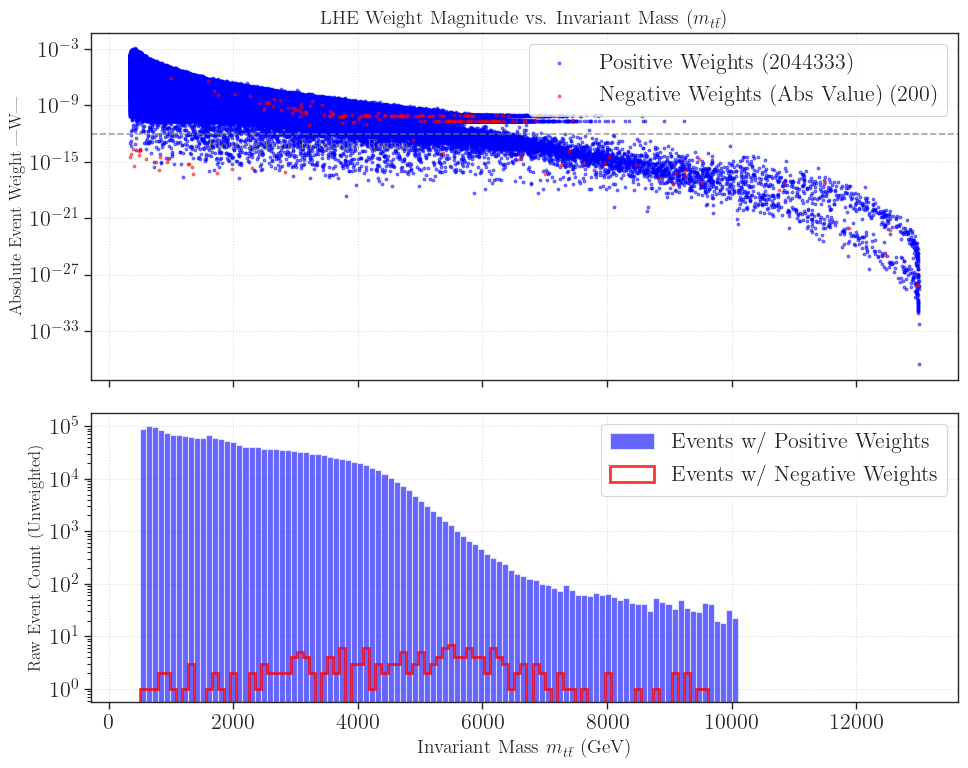

In [24]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

def analyze_lhe_weights_mtt(lhe_path, max_events=None):
    """
    Parses an LHE file, extracts the event weights, and calculates
    the invariant mass (m_tt) of the top/anti-top pair.
    """
    print(f"Scanning {lhe_path} for kinematic weight analysis...")

    open_func = gzip.open if lhe_path.endswith('.gz') else open

    mtt_pos, w_pos = [], []
    mtt_neg, w_neg = [], []

    inside_event = False
    event_line_count = 0
    current_weight = 0.0

    top_p4 = None
    atop_p4 = None

    events_processed = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            line = line.strip()

            if "<event>" in line:
                inside_event = True
                event_line_count = 0
                top_p4 = None
                atop_p4 = None
                continue

            if inside_event:
                event_line_count += 1
                parts = line.split()

                # The first line inside <event> contains the weight
                if event_line_count == 1:
                    if len(parts) >= 3:
                        current_weight = float(parts[2])
                    continue

                # Stop parsing this event when we hit the closing tag
                if "</event>" in line:
                    inside_event = False

                    # Calculate invariant mass if we found both tops
                    if top_p4 is not None and atop_p4 is not None:
                        # 4-momentum: (px, py, pz, E)
                        px = top_p4[0] + atop_p4[0]
                        py = top_p4[1] + atop_p4[1]
                        pz = top_p4[2] + atop_p4[2]
                        E  = top_p4[3] + atop_p4[3]

                        mtt = np.sqrt(max(0, E**2 - px**2 - py**2 - pz**2))

                        # Sort by weight sign
                        if current_weight >= 0:
                            mtt_pos.append(mtt)
                            w_pos.append(current_weight)
                        else:
                            mtt_neg.append(mtt)
                            w_neg.append(current_weight)

                    events_processed += 1
                    if max_events and events_processed >= max_events:
                        break

                    # Print progress
                    #if events_processed % 10000 == 0:
                        #print(f"Processed {events_processed} events...")
                    continue

                # Parse particle lines looking for tops (PDG ID = 6) and anti-tops (-6)
                if len(parts) >= 10:
                    try:
                        pdg_id = int(parts[0])
                        # We grab the 4-momentum: px, py, pz, E (columns 6, 7, 8, 9 in 0-indexed split)
                        if pdg_id == 6:
                            top_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                        elif pdg_id == -6:
                            atop_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                    except ValueError:
                        pass # Header/comment lines inside block if any

    print(f"\nScan complete. Processed {events_processed} events.")
    print(f"  -> Positive weights: {len(w_pos)}")
    print(f"  -> Negative weights: {len(w_neg)}")

    return np.array(mtt_pos), np.array(w_pos), np.array(mtt_neg), np.array(w_neg)

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Generates a 2-panel plot diagnosing the magnitude and phase space
    of the negative weights.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})

    # ---------------------------------------------------------
    # TOP PANEL: Magnitude Check (Scatter)
    # ---------------------------------------------------------
    # Plot positive weights
    ax_mag.scatter(mtt_pos, w_pos, color='blue', alpha=0.5, s=4, label=f'Positive Weights ({len(w_pos)})')

    # Plot absolute value of negative weights
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, label=f'Negative Weights (Abs Value) ({len(w_neg)})')

    # FIX: Added 'r' to the strings so \b in \bar isn't read as a backspace
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag.set_yscale('log') # Log scale is crucial here!
    ax_mag.grid(True, linestyle=':', alpha=0.7)

    # FIX: Removed the invalid 'markersize' argument
    ax_mag.legend(loc='upper right')

    # Draw reference line for floating point precision boundary (approx 1e-12)
    ax_mag.axhline(1e-12, color='gray', linestyle='--', alpha=0.7)
    ax_mag.text(1600, 2e-14, 'Floating-Point Instability Region', color='gray', fontsize=10)

    # ---------------------------------------------------------
    # BOTTOM PANEL: Phase Space Check (Histogram)
    # ---------------------------------------------------------
    bins = np.linspace(500, 10100, 100)

    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, label='Events w/ Positive Weights')

    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, label='Events w/ Negative Weights', histtype='step', linewidth=2)

    # FIX: Added 'r' here as well
    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count (Unweighted)", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('lhe_weight_diagnostics.png', dpi=150)
    plt.show()

# ==========================================
# Execution
# ==========================================
file_path =  './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_negW_test_1000_900/events.lhe.gz'

# Run parser
mtt_pos, w_pos, mtt_neg, w_neg = analyze_lhe_weights_mtt(file_path, max_events=None)

# Plot diagnostics
plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg)

In [29]:
import gzip
import numpy as np

def print_negative_events(lhe_path, max_events=3, threshold=1e-6, m_min=0.0, m_max=float('inf')):
    """
    Args:
        m_min: Minimum invariant mass for top pair (GeV)
        m_max: Maximum invariant mass for top pair (GeV)
    """
    print(f"Scanning {lhe_path}...")
    print(f"Filter: |W| >= {threshold}, Invariant Mass range: [{m_min}, {m_max}]\n")
    
    open_func = gzip.open if lhe_path.endswith('.gz') else open

    inside_event = False
    event_lines = []
    negative_count = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            if "<event>" in line:
                inside_event = True
                event_lines = []
                continue
            
            if "</event>" in line:
                inside_event = False
                if not event_lines: continue
                
                # 1. Check Weight
                info = event_lines[0].split()
                try:
                    weight = float(info[2])
                except (ValueError, IndexError):
                    continue
                
                if weight < 0 and abs(weight) >= threshold:
                    
                    # 2. Extract Particles and Calculate Kinematics
                    all_particles = []
                    top_momenta = []
                    
                    for ev_line in event_lines[1:]:
                        parts = ev_line.split()
                        try:
                            pdg = int(parts[0])
                        except (ValueError, IndexError):
                            continue 
                            
                        # px=col 7, py=col 8, pz=col 9, E=col 10
                        px, py, pz, E = map(float, parts[6:10])
                        all_particles.append({'id': pdg, 'mom': np.array([E, px, py, pz])})
                        
                        if abs(pdg) == 6:
                            top_momenta.append(np.array([E, px, py, pz]))
                    
                    # Calculate Invariant Mass (Tops)
                    inv_mass = 0.0
                    pt_top = 0.0
                    if len(top_momenta) >= 1:
                        # pT = sqrt(px^2 + py^2)
                        pt_top = np.sqrt(top_momenta[0][1]**2 + top_momenta[0][2]**2)
                        
                    if len(top_momenta) == 2:
                        p_tot = top_momenta[0] + top_momenta[1]
                        m2 = p_tot[0]**2 - (p_tot[1]**2 + p_tot[2]**2 + p_tot[3]**2)
                        inv_mass = np.sqrt(max(0, m2))
                        
                    # Calculate Center of Mass Energy (Incoming Partons)
                    cm_energy = 0.0
                    if len(all_particles) >= 2:
                        p_in = all_particles[0]['mom'] + all_particles[1]['mom']
                        s_hat = p_in[0]**2 - (p_in[1]**2 + p_in[2]**2 + p_in[3]**2)
                        cm_energy = np.sqrt(max(0, s_hat))
                    
                    # 3. Check Mass Interval
                    if m_min <= inv_mass <= m_max:
                        negative_count += 1
                        
                        # Print Event
                        print(f"Weight: {weight:.6e}")
                        ids = [p['id'] for p in all_particles]
                        print("IDs:", " ".join(map(str, ids)))
                        
                        # Header
                        print(f"{'E':>15} {'px':>15} {'py':>15} {'pz':>15}")
                        # Kinematics
                        for p in all_particles:
                            mom = p['mom']
                            print(f"{mom[0]: 15.10e} {mom[1]: 15.10e} {mom[2]: 15.10e} {mom[3]: 15.10e}")
                        
                        # Summary Line
                        print(f"Inv. Mass: {inv_mass: 12.4e} | CM Energy: {cm_energy: 12.4e} | pT (top): {pt_top: 12.4e}")
                        print("-" * 65)

                if negative_count >= max_events:
                    break
            
            elif inside_event:
                event_lines.append(line)

# Execution example:
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_negW_test_1000_900/events.lhe.gz'
print_negative_events(file_path, max_events=10, threshold=1e-12, m_min=5800.0, m_max=6100.0)

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_negW_test_1000_900/events.lhe.gz...
Filter: |W| >= 1e-12, Invariant Mass range: [5800.0, 6100.0]

Weight: -7.730306e-11
IDs: 21 21 6 -6
              E              px              py              pz
 2.2246243791e+03  0.0000000000e+00  0.0000000000e+00  2.2246243791e+03
 3.8542027828e+03 -0.0000000000e+00 -0.0000000000e+00 -3.8542027828e+03
 2.2341214129e+03 -2.2220337881e+02  3.4605536715e+02  2.1891975308e+03
 3.8447057490e+03  2.2220337881e+02 -3.4605536715e+02 -3.8187759345e+03
Inv. Mass:   5.8563e+03 | CM Energy:   5.8563e+03 | pT (top):   4.1125e+02
-----------------------------------------------------------------
Weight: -8.511286e-11
IDs: -2 2 6 -6
              E              px              py              pz
 1.4593515160e+03  0.0000000000e+00  0.0000000000e+00  1.4593515160e+03
 5.8006959411e+03  0.0000000000e+00  0.0000000000e+00 -5.8006959411e+03
 3.4274685466e+03 -2.7419526236e+03  9.

Scanning ./../processFolders/Scalar_ff/pp2ttbar_gs4_ydm2/Events/bias_SMpInt_1000_900/unweighted_events.lhe.gz for kinematic weight analysis...

Scan complete. Processed 1000000 events.
  -> Positive weights: 1000000
  -> Negative weights: 0


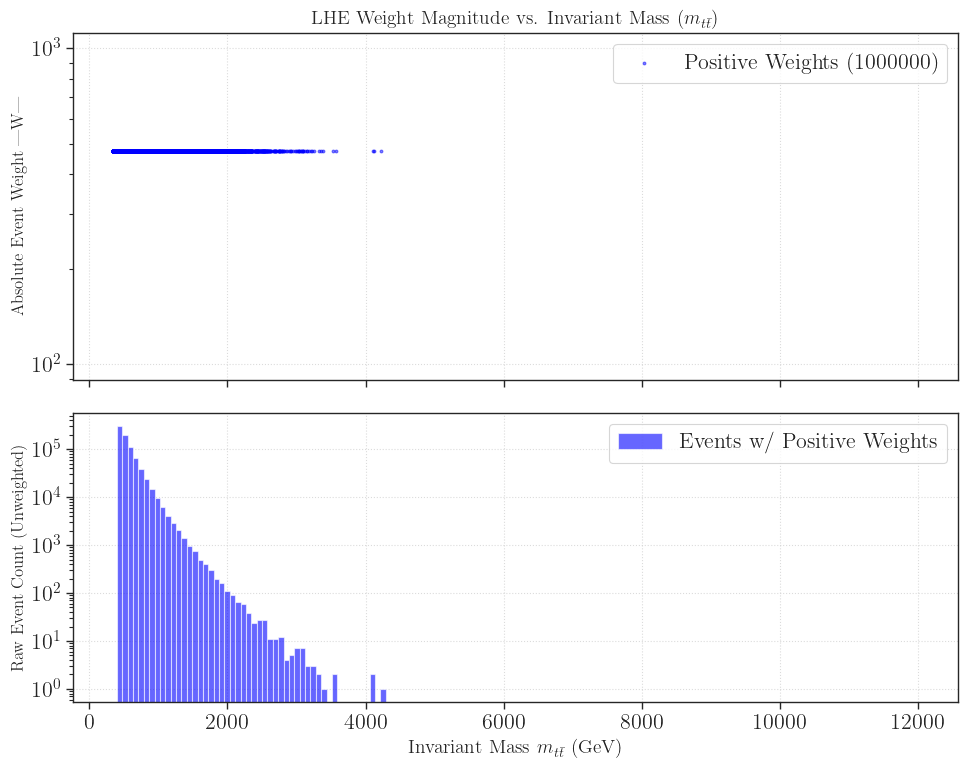

In [5]:
# import gzip
import numpy as np
import matplotlib.pyplot as plt

def analyze_lhe_weights_mtt(lhe_path, max_events=None):
    """
    Parses an LHE file, extracts the event weights, and calculates 
    the invariant mass (m_tt) of the top/anti-top pair.
    """
    print(f"Scanning {lhe_path} for kinematic weight analysis...")
    
    open_func = gzip.open if lhe_path.endswith('.gz') else open
    
    mtt_pos, w_pos = [], []
    mtt_neg, w_neg = [], []
    
    inside_event = False
    event_line_count = 0
    current_weight = 0.0
    
    top_p4 = None
    atop_p4 = None
    
    events_processed = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            line = line.strip()
            
            if "<event>" in line:
                inside_event = True
                event_line_count = 0
                top_p4 = None
                atop_p4 = None
                continue
                
            if inside_event:
                event_line_count += 1
                parts = line.split()
                
                # The first line inside <event> contains the weight
                if event_line_count == 1:
                    if len(parts) >= 3:
                        current_weight = float(parts[2])
                    continue
                
                # Stop parsing this event when we hit the closing tag
                if "</event>" in line:
                    inside_event = False
                    
                    # Calculate invariant mass if we found both tops
                    if top_p4 is not None and atop_p4 is not None:
                        # 4-momentum: (px, py, pz, E)
                        px = top_p4[0] + atop_p4[0]
                        py = top_p4[1] + atop_p4[1]
                        pz = top_p4[2] + atop_p4[2]
                        E  = top_p4[3] + atop_p4[3]
                        
                        mtt = np.sqrt(max(0, E**2 - px**2 - py**2 - pz**2))
                        
                        # Sort by weight sign
                        if current_weight >= 0:
                            mtt_pos.append(mtt)
                            w_pos.append(current_weight)
                        else:
                            mtt_neg.append(mtt)
                            w_neg.append(current_weight)
                            
                    events_processed += 1
                    if max_events and events_processed >= max_events:
                        break
                    
                    # Print progress
                    #if events_processed % 10000 == 0:
                        #print(f"Processed {events_processed} events...")
                    continue
                
                # Parse particle lines looking for tops (PDG ID = 6) and anti-tops (-6)
                if len(parts) >= 10:
                    try:
                        pdg_id = int(parts[0])
                        # We grab the 4-momentum: px, py, pz, E (columns 6, 7, 8, 9 in 0-indexed split)
                        if pdg_id == 6:
                            top_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                        elif pdg_id == -6:
                            atop_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                    except ValueError:
                        pass # Header/comment lines inside block if any

    print(f"\nScan complete. Processed {events_processed} events.")
    print(f"  -> Positive weights: {len(w_pos)}")
    print(f"  -> Negative weights: {len(w_neg)}")
    
    return np.array(mtt_pos), np.array(w_pos), np.array(mtt_neg), np.array(w_neg)

def plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg):
    """
    Generates a 2-panel plot diagnosing the magnitude and phase space 
    of the negative weights.
    """
    fig, (ax_mag, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
    
    # ---------------------------------------------------------
    # TOP PANEL: Magnitude Check (Scatter)
    # ---------------------------------------------------------
    # Plot positive weights
    ax_mag.scatter(mtt_pos, w_pos, color='blue', alpha=0.5, s=4, label=f'Positive Weights ({len(w_pos)})')
    
    # Plot absolute value of negative weights
    if len(w_neg) > 0:
        ax_mag.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, label=f'Negative Weights (Abs Value) ({len(w_neg)})')
        
    # FIX: Added 'r' to the strings so \b in \bar isn't read as a backspace
    ax_mag.set_title(r"LHE Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag.set_yscale('log') # Log scale is crucial here!
    ax_mag.grid(True, linestyle=':', alpha=0.7)
    
    # FIX: Removed the invalid 'markersize' argument
    ax_mag.legend(loc='upper right')
    
    # Draw reference line for floating point precision boundary (approx 1e-12)
    #ax_mag.axhline(1e-12, color='gray', linestyle='--', alpha=0.7)
    #ax_mag.text(1600, 2e-14, 'Floating-Point Instability Region', color='gray', fontsize=10)

    # ---------------------------------------------------------
    # BOTTOM PANEL: Phase Space Check (Histogram)
    # ---------------------------------------------------------
    bins = np.linspace(400, 12000, 150)

    ax_hist.hist(mtt_pos, bins=bins, color='blue', alpha=0.6, label='Events w/ Positive Weights')
    
    if len(w_neg) > 0:
        ax_hist.hist(mtt_neg, bins=bins, color='red', alpha=0.8, label='Events w/ Negative Weights', histtype='step', linewidth=2)

    # FIX: Added 'r' here as well
    ax_hist.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist.set_ylabel("Raw Event Count (Unweighted)", fontsize=12)
    ax_hist.set_yscale('log')
    ax_hist.grid(True, linestyle=':', alpha=0.7)
    ax_hist.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('lhe_weight_diagnostics.png', dpi=150)
    plt.show()

# ==========================================
# Execution
# ==========================================
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_negW_test_1000_900/events.lhe.gz'
file_path = './../processFolders/Scalar_ff/pp2ttbar_gs4_ydm2/Events/bias_SMpInt_1000_900/unweighted_events.lhe.gz'



# Run parser
mtt_pos, w_pos, mtt_neg, w_neg = analyze_lhe_weights_mtt(file_path, max_events=None)

# Plot diagnostics
plot_weight_diagnostics(mtt_pos, w_pos, mtt_neg, w_neg)

Scanning ./../processFolders/Scalar_ff/pp2ttbar_gs4_ydm4/Events/bias_fullAmp_1000_900/unweighted_events.lhe.gz for kinematic weight analysis...

Scan complete. Processed 1000000 events.
  -> Positive weights: 1000000
  -> Negative weights: 0


/tmp/ipykernel_5378/2675713568.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


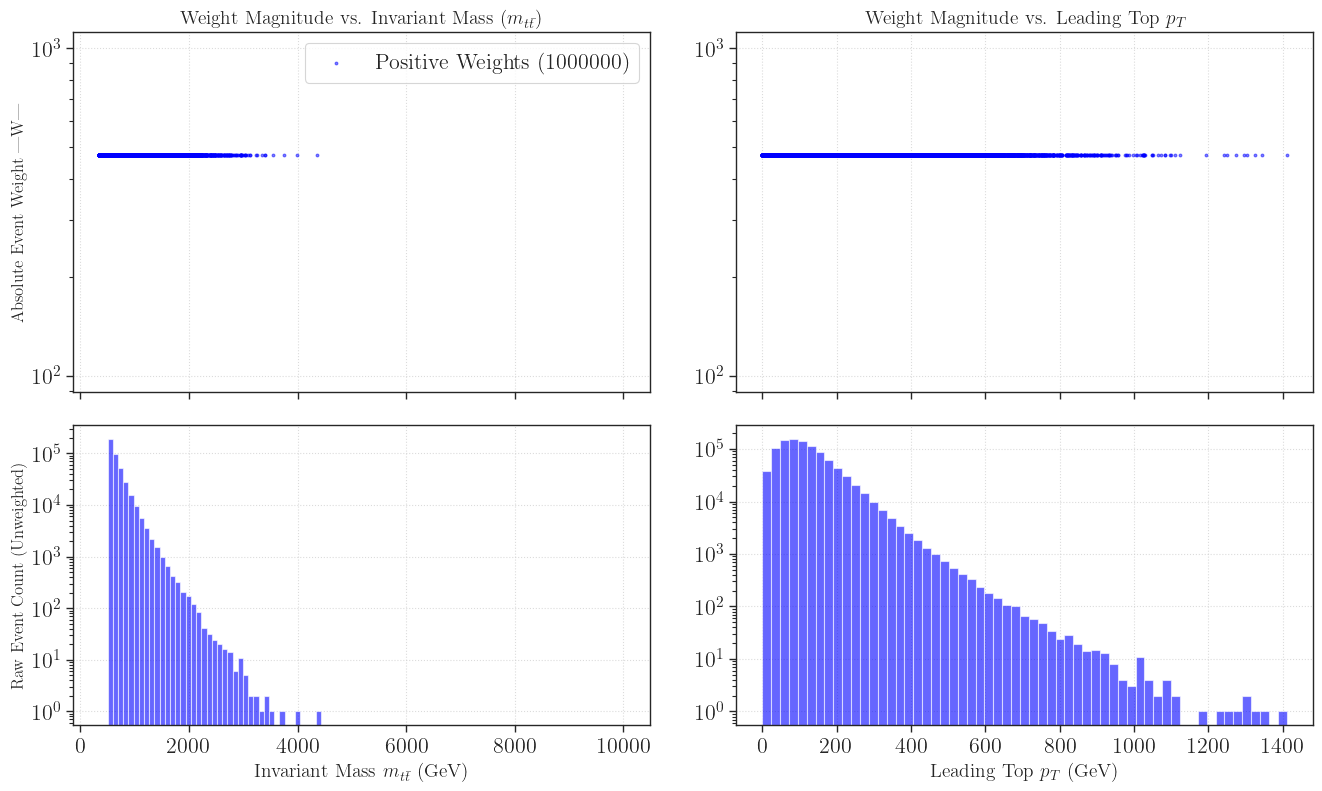

 CROSS-SECTION IMPACT ANALYSIS
Total Positive Yield: 4.736200e+08
Total Negative Yield (Abs): 0.000000e+00
--------------------------------------------------
Fractional Impact: 0.000000e+00
Percentage Impact: 0.000000000000%
CONCLUSION: 100% CERTAIN. Negative weights are numerical noise.
They are millions of times too small to be physical.


In [6]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

def analyze_lhe_weights(lhe_path, max_events=None):
    """
    Parses an LHE file, extracts the event weights, and calculates 
    the invariant mass (m_tt) and leading top p_T.
    """
    print(f"Scanning {lhe_path} for kinematic weight analysis...")
    
    open_func = gzip.open if lhe_path.endswith('.gz') else open
    
    mtt_pos, pt_pos, w_pos = [], [], []
    mtt_neg, pt_neg, w_neg = [], [], []
    
    inside_event = False
    event_line_count = 0
    current_weight = 0.0
    
    top_p4 = None
    atop_p4 = None
    
    events_processed = 0

    with open_func(lhe_path, 'rt') as f:
        for line in f:
            line = line.strip()
            
            if "<event>" in line:
                inside_event = True
                event_line_count = 0
                top_p4 = None
                atop_p4 = None
                continue
                
            if inside_event:
                event_line_count += 1
                parts = line.split()
                
                # The first line inside <event> contains the weight
                if event_line_count == 1:
                    if len(parts) >= 3:
                        current_weight = float(parts[2])
                    continue
                
                # Stop parsing this event when we hit the closing tag
                if "</event>" in line:
                    inside_event = False
                    
                    # Calculate kinematics if we found both tops
                    if top_p4 is not None and atop_p4 is not None:
                        # 4-momentum: (px, py, pz, E)
                        px = top_p4[0] + atop_p4[0]
                        py = top_p4[1] + atop_p4[1]
                        pz = top_p4[2] + atop_p4[2]
                        E  = top_p4[3] + atop_p4[3]
                        
                        mtt = np.sqrt(max(0, E**2 - px**2 - py**2 - pz**2))
                        
                        # Calculate transverse momentum for both, pick the leading one
                        pt_top = np.sqrt(top_p4[0]**2 + top_p4[1]**2)
                        pt_atop = np.sqrt(atop_p4[0]**2 + atop_p4[1]**2)
                        leading_pt = max(pt_top, pt_atop)
                        
                        # Sort by weight sign
                        if current_weight >= 0:
                            mtt_pos.append(mtt)
                            pt_pos.append(leading_pt)
                            w_pos.append(current_weight)
                        else:
                            mtt_neg.append(mtt)
                            pt_neg.append(leading_pt)
                            w_neg.append(current_weight)
                            
                    events_processed += 1
                    if max_events and events_processed >= max_events:
                        break
                    continue
                
                # Parse particle lines looking for tops (PDG ID = 6) and anti-tops (-6)
                if len(parts) >= 10:
                    try:
                        pdg_id = int(parts[0])
                        # We grab the 4-momentum: px, py, pz, E (columns 6, 7, 8, 9 in 0-indexed split)
                        if pdg_id == 6:
                            top_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                        elif pdg_id == -6:
                            atop_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                    except ValueError:
                        pass # Header/comment lines inside block if any

    print(f"\nScan complete. Processed {events_processed} events.")
    print(f"  -> Positive weights: {len(w_pos)}")
    print(f"  -> Negative weights: {len(w_neg)}")
    
    return (np.array(mtt_pos), np.array(pt_pos), np.array(w_pos), 
            np.array(mtt_neg), np.array(pt_neg), np.array(w_neg))

def plot_weight_diagnostics(mtt_pos, pt_pos, w_pos, mtt_neg, pt_neg, w_neg):
    """
    Generates a 2x2 plot diagnosing the magnitude and phase space 
    of the negative weights for both m_tt and leading p_T.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col', gridspec_kw={'height_ratios': [1.2, 1], 'wspace': 0.15, 'hspace': 0.1})
    
    ax_mag_mtt, ax_mag_pt = axes[0]
    ax_hist_mtt, ax_hist_pt = axes[1]
    
    # =========================================================
    # COLUMN 1: INVARIANT MASS (m_tt)
    # =========================================================
    # Magnitude Check
    ax_mag_mtt.scatter(mtt_pos, w_pos, color='blue', alpha=0.5, s=4, label=f'Positive Weights ({len(w_pos)})')
    if len(w_neg) > 0:
        ax_mag_mtt.scatter(mtt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4, label=f'Negative Weights (Abs Value) ({len(w_neg)})')
        
    ax_mag_mtt.set_title(r"Weight Magnitude vs. Invariant Mass ($m_{t\bar{t}}$)", fontsize=14)
    ax_mag_mtt.set_ylabel("Absolute Event Weight |W|", fontsize=12)
    ax_mag_mtt.set_yscale('log')
    ax_mag_mtt.grid(True, linestyle=':', alpha=0.7)
    ax_mag_mtt.legend(loc='upper right')
    #ax_mag_mtt.axhline(1e-12, color='gray', linestyle='--', alpha=0.7)
    #ax_mag_mtt.text(1600, 2e-14, 'Floating-Point Instability Region', color='gray', fontsize=10)

    # Phase Space Histogram
    mtt_bins = np.linspace(500, 10000, 100)
    ax_hist_mtt.hist(mtt_pos, bins=mtt_bins, color='blue', alpha=0.6, label='Events w/ Positive Weights')
    if len(w_neg) > 0:
        ax_hist_mtt.hist(mtt_neg, bins=mtt_bins, color='red', alpha=0.8, label='Events w/ Negative Weights', histtype='step', linewidth=2)

    ax_hist_mtt.set_xlabel(r"Invariant Mass $m_{t\bar{t}}$ (GeV)", fontsize=14)
    ax_hist_mtt.set_ylabel("Raw Event Count (Unweighted)", fontsize=12)
    ax_hist_mtt.set_yscale('log')
    ax_hist_mtt.grid(True, linestyle=':', alpha=0.7)

    # =========================================================
    # COLUMN 2: LEADING TOP p_T
    # =========================================================
    # Magnitude Check
    ax_mag_pt.scatter(pt_pos, w_pos, color='blue', alpha=0.5, s=4)
    if len(w_neg) > 0:
        ax_mag_pt.scatter(pt_neg, np.abs(w_neg), color='red', alpha=0.5, s=4)
        
    ax_mag_pt.set_title(r"Weight Magnitude vs. Leading Top $p_T$", fontsize=14)
    ax_mag_pt.set_yscale('log')
    ax_mag_pt.grid(True, linestyle=':', alpha=0.7)
    #ax_mag_pt.axhline(1e-12, color='gray', linestyle='--', alpha=0.7)
    #ax_mag_pt.text(max(pt_pos)*0.05, 2e-14, 'Floating-Point Instability Region', color='gray', fontsize=10)

    # Phase Space Histogram
    # Dynamically scale the p_T bins based on the data range
    all_pts = np.concatenate([pt_pos, pt_neg]) if len(w_neg) > 0 else pt_pos
    pt_bins = np.linspace(min(all_pts), max(all_pts), 60)
    
    ax_hist_pt.hist(pt_pos, bins=pt_bins, color='blue', alpha=0.6)
    if len(w_neg) > 0:
        ax_hist_pt.hist(pt_neg, bins=pt_bins, color='red', alpha=0.8, histtype='step', linewidth=2)

    ax_hist_pt.set_xlabel(r"Leading Top $p_T$ (GeV)", fontsize=14)
    ax_hist_pt.set_yscale('log')
    ax_hist_pt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('lhe_weight_diagnostics_2x2.png', dpi=150)
    plt.show()

# ==========================================
# Execution
# ==========================================
file_path = './../../UnfoldingBSMttbar/processFolders/VLF/pp2ttbar_gs4_ydm2/Events/bias_best_fit_1300_1200/events.lhe.gz'
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_best_fit_1000_900/events.lhe.gz'
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'
file_path = './../processFolders/Scalar_ff/pp2ttbar_gs4_ydm4/Events/bias_fullAmp_1000_900/unweighted_events.lhe.gz'

# Run parser
mtt_pos, pt_pos, w_pos, mtt_neg, pt_neg, w_neg = analyze_lhe_weights(file_path, max_events=None)

# Plot diagnostics
plot_weight_diagnostics(mtt_pos, pt_pos, w_pos, mtt_neg, pt_neg, w_neg)

import numpy as np

# Calculate total cross-section (sum of weights)
yield_pos = np.sum(w_pos)
yield_neg_abs = np.sum(np.abs(w_neg))

# Calculate the fractional impact
fractional_impact = yield_neg_abs / yield_pos
percentage_impact = fractional_impact * 100

print("==================================================")
print(" CROSS-SECTION IMPACT ANALYSIS")
print("==================================================")
print(f"Total Positive Yield: {yield_pos:.6e}")
print(f"Total Negative Yield (Abs): {yield_neg_abs:.6e}")
print("--------------------------------------------------")
print(f"Fractional Impact: {fractional_impact:.6e}")
print(f"Percentage Impact: {percentage_impact:.12f}%")
print("==================================================")

if percentage_impact < 1e-5:
    print("CONCLUSION: 100% CERTAIN. Negative weights are numerical noise.")
    print("They are millions of times too small to be physical.")
else:
    print("CONCLUSION: Negative weights are large enough to be physical.")

In [7]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def analyze_signed_weights(lhe_path, max_events=None):
    print(f"Scanning {lhe_path} for FKS Subtraction mirroring...")
    open_func = gzip.open if lhe_path.endswith('.gz') else open
    
    pt_leading = []
    weights = []
    
    inside_event = False
    event_line_count = 0
    current_weight = 0.0
    top_p4, atop_p4 = None, None
    events_processed = 0

    try:
        with open_func(lhe_path, 'rt') as f:
            for line in f:
                line = line.strip()
                
                if "<event>" in line:
                    inside_event = True
                    event_line_count = 0
                    top_p4, atop_p4 = None, None
                    continue
                    
                if inside_event:
                    event_line_count += 1
                    parts = line.split()
                    
                    if event_line_count == 1:
                        if len(parts) >= 3:
                            current_weight = float(parts[2])
                        continue
                    
                    if "</event>" in line:
                        inside_event = False
                        if top_p4 is not None and atop_p4 is not None:
                            pt_top = np.sqrt(top_p4[0]**2 + top_p4[1]**2)
                            pt_atop = np.sqrt(atop_p4[0]**2 + atop_p4[1]**2)
                            
                            pt_leading.append(max(pt_top, pt_atop))
                            weights.append(current_weight)
                                
                        events_processed += 1
                        if max_events and events_processed >= max_events:
                            break
                        continue
                    
                    if len(parts) >= 10:
                        try:
                            pdg_id = int(parts[0])
                            if pdg_id == 6:
                                top_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                            elif pdg_id == -6:
                                atop_p4 = (float(parts[6]), float(parts[7]), float(parts[8]), float(parts[9]))
                        except ValueError:
                            pass
                            
    except EOFError:
        print(f"\n[WARNING] Reached a corrupted section of the file (EOFError)!")
        print(f"The file {lhe_path} is truncated.")
        print(f"Salvaging the {events_processed} events that were successfully read prior to the crash...\n")

    print(f"Processed {events_processed} events.")
    return np.array(pt_leading), np.array(weights)

def extract_fks_pairs(pt, w, tolerance=1e-4):
    """
    Finds exact kinematic matches between positive and negative weight events.
    """
    print("Matching FKS counterterm pairs by kinematics...")
    mask_pos = w >= 0
    mask_neg = w < 0
    
    pt_pos = pt[mask_pos]
    w_pos = w[mask_pos]
    
    pt_neg = pt[mask_neg]
    w_neg = w[mask_neg]
    
    # Sort positive events for fast binary searching
    sort_idx = np.argsort(pt_pos)
    pt_pos_sorted = pt_pos[sort_idx]
    w_pos_sorted = w_pos[sort_idx]
    
    paired_pt = []
    paired_w_pos = []
    paired_w_neg = []
    
    # Track used positive indices to avoid double-matching the same event
    used_pos_indices = set()
    
    for i in range(len(pt_neg)):
        p_n = pt_neg[i]
        w_n = w_neg[i]
        
        # Find the closest positive p_T index
        idx = np.searchsorted(pt_pos_sorted, p_n)
        
        best_idx = -1
        min_diff = float('inf')
        
        # Check the closest neighbors (handles exact matches and slight rounding differences)
        for check_idx in [idx - 1, idx, idx + 1]:
            if 0 <= check_idx < len(pt_pos_sorted):
                diff = abs(pt_pos_sorted[check_idx] - p_n)
                if diff < min_diff and check_idx not in used_pos_indices:
                    min_diff = diff
                    best_idx = check_idx
                    
        # If the kinematic match is closer than our tolerance, it's an FKS pair
        if min_diff < tolerance and best_idx != -1:
            paired_pt.append(p_n)
            paired_w_neg.append(w_n)
            paired_w_pos.append(w_pos_sorted[best_idx])
            used_pos_indices.add(best_idx)
            
    print(f"Found {len(paired_pt)} perfectly matched FKS pairs out of {len(pt_neg)} negative events.")
    return np.array(paired_pt), np.array(paired_w_pos), np.array(paired_w_neg)

def plot_fks_isolated_pairs(pt_pairs, w_pos, w_neg):
    """
    Plots only the verified pairs, drawing a line between them to show the cancellation.
    """
    if len(pt_pairs) == 0:
        print("No pairs found to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Draw vertical connecting lines between pairs to prove they share the exact p_T
    segments = [[(p, wp), (p, wn)] for p, wp, wn in zip(pt_pairs, w_pos, w_neg)]
    lc = LineCollection(segments, colors='gray', alpha=0.3, linewidths=0.5, zorder=0)
    ax.add_collection(lc)
    
    # Plot the isolated pairs
    ax.scatter(pt_pairs, w_pos, color='blue', alpha=0.8, s=8, label='Real Emission (+W)')
    ax.scatter(pt_pairs, w_neg, color='red', alpha=0.8, s=8, label='FKS Counterterm (-W)')
    
    ax.set_title("Isolated FKS Subtraction Pairs (Matched by Kinematics)", fontsize=14)
    ax.set_xlabel(r"Leading Top $p_T$ (GeV)", fontsize=14)
    ax.set_ylabel("Raw Event Weight (Linear)", fontsize=14)
    
    # Draw zero reference line
    ax.axhline(0, color='black', linewidth=1.5, linestyle='-')
    
    # Auto-scale x-axis to the actual data range of the pairs
    ax.set_xlim(0, max(pt_pairs) * 1.1) 
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('fks_isolated_pairs.png', dpi=150)
    plt.show()

# ==========================================
# Execution
# ==========================================
file_path = './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'

# 1. Parse the file
pt, w = analyze_signed_weights(file_path)

# 2. Extract only the exact FKS pairs
pt_pairs, w_pos_pairs, w_neg_pairs = extract_fks_pairs(pt, w, tolerance=1e-4)

# 3. Plot only the pairs
plot_fks_isolated_pairs(pt_pairs, w_pos_pairs, w_neg_pairs)

Scanning ./../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz for FKS Subtraction mirroring...


FileNotFoundError: [Errno 2] No such file or directory: './../../UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/w_test/events.lhe.gz'

In [ ]:
# Sum everything, don't look for pairs
total_pos = np.sum(w[w >= 0])
total_neg = np.sum(w[w < 0])

print(f"Total Positive Weight: {total_pos:.6e}")
print(f"Total Negative Weight: {total_neg:.6e}")
print(f"Net Cross-Section:    {total_pos + total_neg:.6e}")